<header>
    
Investigating geochemical data from granites using advanced dimensionality reduction techniques and compositional data analysis tools
====
    
</header>

**Contributors:**
*Christopher Mark Yeomans (CMY), Jordan James Lindsay (JJL)*

This notebook shows the workflow used to re-analyse data from the [Simons et al. (2016)](https://www.sciencedirect.com/science/article/pii/S0024493716300950#ec0005) paper on granite classification. The work focuses on classifying the major granite types, subtypes are less easily defined due to the textural variation upon which these divisions are made, but there are occasional dabblings to try and see what happens with subtypes in the data structure - spoiler, not very conclusive!

The motivation for this research is to unpick the chemical signatures of the granites so that they can be more accurately determined through semi-automated and automated means such as machine learning methods. This was deemed necessary following mixed results from re-mapping surface exposures of the granites during CMY's PhD research.

The approach is not conducted from a geochemical point of view so much but from the perspective of a data scientist trying to unpick the problem knowing that 5 classes exist (perhaps a fallible assumption!). The workflow for Section 1 is based on research by JJL and his machine learning approach to investigating basalt geochemistry. Section 2 is far more 'blue sky' in it's approach to using Compositional Data Analysis (CoDa) and, to illustrate the thought-process, includes many of the pitfalls CMY fell into himself during the analysis.

This notebook is shared with a view to gaining feedback and criticism of both the method and any tentative interpretations, as well as comments that may enhance the analysis. All remarks will of course gain proper attribution as co-author or acknwoledgement, as appropriate, in any future publication(s). 

## Initial packages to load

In [1]:
## This should use the 'geo' environment
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # not installed in the current environment
%matplotlib inline

# Geochemical investigations of the raw data

In this section, we take the raw data downloaded from the supplementary information of [Simons et al. (2016)](https://www.sciencedirect.com/science/article/pii/S0024493716300950#ec0005) which can be found in [Supplementary Table 2](https://ars.els-cdn.com/content/image/1-s2.0-S0024493716300950-mmc2.xlsx) (requires access) but is provided here in a transposed form.

## Import the initial geochemical data

Here we will import geochemical data from Simons et al. (2016)

In [2]:
df_geochem = pd.read_csv("./data/orig_geochem_Simons/Simons_2016_transposed.csv", header=0, encoding = "ISO-8859-1",skiprows=[1,2])
#df_geochem.columns

## Manipulate the data

Some of the columns are superfluous or have NaNs, they also need to be converted to Z-scores.

Also, because the Granite Types are generally divided by *chemistry* and then **texture**, e.g. G *3* **a**, it is not possible to split these by texture based on geochemical, geophysical or regional geological features. Therefore, the column 'Type' needs to be split.

We will deal with NaNs first:

In [6]:
# Remove rows with NaNs
df_ = df_geochem.dropna(axis='rows')
# Remove any columns that survived with NaNs (should be zero)
df = df_.dropna(axis='columns')
# Check the shape of the resultant dataframes
df.shape, df_.shape, df_geochem.shape

((62, 44), (62, 44), (73, 44))

### Split the 'Type' string:

In [7]:
# Create some new columns
df["Main Granite"] = ""
df["Subtype"] = ""
# Convert to string
df['Type'] = df['Type'].astype('str') 
df['Main Granite'] = df['Main Granite'].astype('str') 
df['Type']
# Split by each one
df[['Main Granite', 'Subtype']] = df['Type'].str.split(pat='a', expand=True) 
df[['Main Granite', 'Subtype']] = df['Main Granite'].str.split(pat='b', expand=True)
df[['Main Granite', 'Subtype']] = df['Main Granite'].str.split(pat='c', expand=True)
df[['Main Granite', 'Subtype']] = df['Main Granite'].str.split(pat='d', expand=True)
# Kill this column
del df['Subtype']

### Map the granite type to a numeric column

In [8]:
def f(df_col):
    if df_col == 'G1':
        val = 1
    elif df_col == 'G2':
        val = 2
    elif df_col == 'G3':
        val = 3
    elif df_col == 'G4':
        val = 4
    elif df_col == 'G5':
        val = 5
    else:
        val = NaN
    return val
df['G'] = df['Main Granite'].apply(f)

In [9]:
# Bring the new columns next to original
MG = df['Main Granite']
G = df['G']
df.drop(columns=['Main Granite','G'],axis = 1, inplace = True)
df.insert(2, 'Main Granite', MG)
df.insert(3, 'G', G)

### Drop unnecessary columns such as LOI and Total (Optional)

Only run this cell if you want them gone, alternatively see next code block that just removes them from the z_score calculation

In [10]:
#df.drop(columns=['LOI','Total'],axis = 1, inplace = True)

In [19]:
#cols = list(df.columns)

### Create some Z-scores

In [49]:
cols = list(df.columns)
rm = ['Sample','Type','Main Granite','G','Pluton','Grid reference','Easting','Northing', 'LOI', 'Total']
for i in rm:
    cols.remove(i)
for col in cols:
    col_zscore = col + '_zscore'
    df[col_zscore] = (df[col] - df[col].mean())/df[col].std(ddof=0)
df

,Sample,Type,Main Granite,G,Pluton,Grid reference,Easting,Northing,SiO2,TiO2,...,Ho_zscore,Er_zscore,Tm_zscore,Yb_zscore,Lu_zscore,A/CNK_zscore,TZr_zscore,Eu/Eu*_zscore,K/Rb_zscore,Rb/Sr_zscore
0,LE01,G3a,G3,3,Land's End,SW45152425,145150,24250,70.41,0.39,...,3.125831,2.989713,2.451225,2.721027,2.250255,-0.282027,0.951747,0.294964,1.237568,-0.593386
1,LE02,G3a,G3,3,Land's End,SW45152425,145150,24250,69.77,0.39,...,2.554626,2.484639,2.049703,2.193592,1.650617,0.030217,1.412749,0.138658,0.578948,-0.576401
2,LE03,G3a,G3,3,Land's End,SW44672535,144670,25350,70.86,0.35,...,2.228224,2.232102,1.848942,2.080571,1.450738,0.030217,1.259082,0.060505,0.429262,-0.587095
3,LE04,G4b,G4,4,Land's End,SW38642885,138640,28850,73.50,0.11,...,-0.709399,-0.545806,-0.359427,-0.066841,-0.148298,1.123073,-0.760548,-1.580705,-1.486723,2.857124
4,LE05,G4b,G4,4,Land's End,SW38642885,138640,28850,73.91,0.10,...,-0.709399,-0.545806,-0.359427,-0.029167,-0.148298,0.342462,-1.023978,-1.580705,-1.307100,2.906193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,DT19,G3a,G3,3,Dartmoor,SX75127691,275120,76910,71.43,0.32,...,0.106607,0.243372,0.042095,0.385246,0.451341,-1.687128,0.907842,0.685728,0.938195,-0.702217
69,DT20,G3a,G3,3,Dartmoor,SX75127691,275120,76910,71.41,0.32,...,0.106607,0.274940,0.042095,0.385246,0.451341,-1.999372,0.885889,0.529423,0.848384,-0.689006
70,DT21,G2,G2,2,Dartmoor,sx57235844,257230,58440,72.89,0.20,...,-0.546198,-0.640507,-0.560187,-0.330558,-0.548056,0.810829,0.161457,1.936174,0.010140,-0.309670
71,DT25,G3a,G3,3,Dartmoor,SX61479264,261470,82640,70.42,0.45,...,1.983422,2.263669,2.049703,2.645679,2.050376,0.030217,2.027419,-0.252106,-0.408982,-0.467570


## Exploratory data analysis

This is really testing and replicating the work from Simons et al. (2016)

### Generate z-scores

Let's just describe the Z-score columns

In [8]:
df[df.columns[46:]].describe()

,SiO2_zscore,TiO2_zscore,Al2O3_zscore,Fe2O3_zscore,MnO_zscore,MgO_zscore,CaO_zscore,Na2O_zscore,K2O_zscore,P2O5_zscore,...,Ho_zscore,Er_zscore,Tm_zscore,Yb_zscore,Lu_zscore,A/CNK_zscore,TZr_zscore,Eu/Eu*_zscore,K/Rb_zscore,Rb/Sr_zscore
count,6.200000e+01,6.200000e+01,6.200000e+01,6.200000e+01,6.200000e+01,6.200000e+01,6.200000e+01,6.200000e+01,6.200000e+01,6.200000e+01,...,6.200000e+01,6.200000e+01,6.200000e+01,6.200000e+01,6.200000e+01,6.200000e+01,6.200000e+01,6.200000e+01,6.200000e+01,6.200000e+01
mean,-6.628994e-15,3.151601e-16,-4.308382e-15,-5.730183e-17,-2.292073e-16,6.088320e-17,3.267995e-16,-5.336233e-16,1.221245e-15,3.438110e-16,...,-5.730183e-17,-8.595275e-17,-1.719055e-16,-5.873438e-16,-4.440892e-16,6.446456e-17,3.939501e-16,1.432546e-17,1.360919e-16,1.647428e-16
std,1.008163e+00,1.008163e+00,1.008163e+00,1.008163e+00,1.008163e+00,1.008163e+00,1.008163e+00,1.008163e+00,1.008163e+00,1.008163e+00,...,1.008163e+00,1.008163e+00,1.008163e+00,1.008163e+00,1.008163e+00,1.008163e+00,1.008163e+00,1.008163e+00,1.008163e+00,1.008163e+00
min,-2.259378e+00,-1.784796e+00,-2.435758e+00,-2.062879e+00,-1.589808e+00,-1.787760e+00,-2.461619e+00,-4.406949e+00,-1.415894e+00,-2.845604e+00,...,-1.688607e+00,-1.587521e+00,-1.363231e+00,-1.385427e+00,-1.147695e+00,-2.155494e+00,-2.648462e+00,-1.658858e+00,-2.175281e+00,-7.072495e-01
25%,-7.210611e-01,-7.467346e-01,-3.117226e-01,-5.810294e-01,-6.939378e-01,-8.396635e-01,-6.832460e-01,-3.464470e-01,-5.888521e-01,-5.096308e-01,...,-5.461978e-01,-6.089401e-01,-7.609483e-01,-7.072968e-01,-7.479358e-01,-4.381496e-01,-5.959040e-01,-7.210232e-01,-6.484799e-01,-5.875669e-01
50%,-9.876449e-02,8.371464e-02,-4.765344e-02,-1.994932e-16,-2.203551e-02,1.084334e-01,-1.037760e-01,7.154585e-02,-1.961561e-01,-2.637389e-01,...,-3.013959e-01,-3.090524e-01,-3.594266e-01,-3.493949e-01,-2.482373e-01,3.021721e-02,1.943858e-01,-1.764742e-02,5.504595e-02,-4.578189e-01
75%,5.534023e-01,6.546485e-01,4.269057e-01,4.729309e-01,2.019319e-01,5.681167e-01,4.856848e-01,5.193954e-01,3.274386e-01,4.432003e-01,...,2.698086e-01,3.301820e-01,2.428558e-01,3.664089e-01,2.514612e-01,4.595534e-01,6.389238e-01,5.294226e-01,6.014011e-01,1.940665e-01
max,2.519859e+00,2.575062e+00,3.810053e+00,2.945684e+00,4.681281e+00,2.062087e+00,4.172313e+00,2.093267e+00,5.271839e+00,2.686964e+00,...,3.125831e+00,2.989713e+00,3.655790e+00,2.721027e+00,4.648808e+00,2.996540e+00,2.027419e+00,3.968148e+00,4.021734e+00,3.489351e+00


### Exploratory data plotting

#### Setting params

This next bit creates a list of the columns for plotting

In [16]:
plot_list = df.columns[46:]

And this sets the color to be consistent across all plots going forward

In [10]:
# Color categories
from palettable.colorbrewer.qualitative import Accent_5
c = df['G']
cmap = Accent_5.mpl_colormap
# G1 = Green
# G2 = Purple
# G3 = Orange
# G4 = Yellow
# G5 = Blue
#
# This line sets a scatter plot with the right handles and labels for calling later
ANK = df['Al2O3']/(df['Na2O']+df['K2O'])
scatter1 = plt.scatter(df['A/CNK'],ANK, c=c, cmap=cmap)
plt.close()
handles, labels = scatter1.legend_elements()

#### Histograms

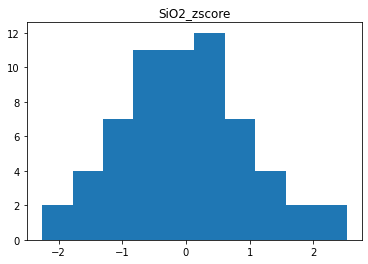

In [17]:
plot = plot_list[0] # Twiddle this number from 0 up to 33
plt.figure()
plt.hist(df[plot])
plt.title(plot)
plt.show()

#### Scatter plots

These scatter plots mimic those of Simons et al. (2016) and use the original data, not z-scores

##### A/CNK

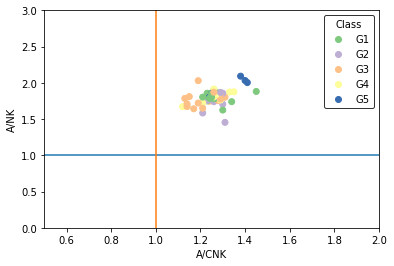

In [13]:
ANK = df['Al2O3']/(df['Na2O']+df['K2O'])
x1 = np.arange(0.4,2.1,0.2)
y1 = np.full(9, 1)

x2 = np.full(9, 1)
y2 = np.arange(0,3.6,0.4)

plt.figure()
plt.scatter(df['A/CNK'],ANK, c=c, cmap=cmap)
plt.plot(x1,y1)
plt.plot(x2,y2)
plt.xlim(0.5,2)
plt.ylim(0,3)
plt.xlabel('A/CNK')
plt.ylabel('A/NK')
plt.legend(handles,
           ["G1","G2","G3","G4","G5"],
           loc="upper right",
           edgecolor = "black",
           title='Class')
plt.show()

##### SiO2 vs TiO2

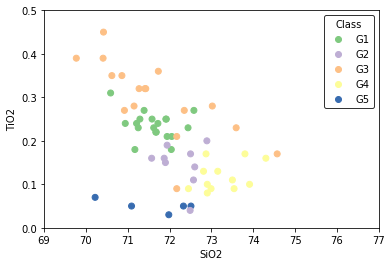

In [580]:
plt.figure()
plt.scatter(df['SiO2'],df['TiO2'], c=c, cmap=cmap)
plt.xlim(69,77)
plt.ylim(0,0.5)
plt.xlabel('SiO2')
plt.ylabel('TiO2')
plt.legend(handles,
           ["G1","G2","G3","G4","G5"],
           loc="upper right",
           edgecolor = "black",
           title='Class')
plt.show()

##### SiO2 vs Na2O

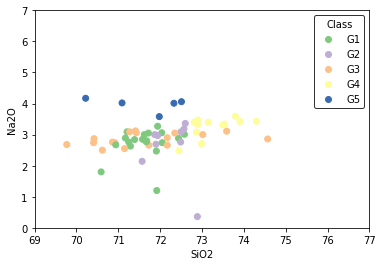

In [581]:
plt.figure()
plt.scatter(df['SiO2'],df['Na2O'], c=c, cmap=cmap)
plt.xlim(69,77)
plt.ylim(0,7)
plt.xlabel('SiO2')
plt.ylabel('Na2O')
plt.legend(handles,
           ["G1","G2","G3","G4","G5"],
           loc="upper right",
           edgecolor = "black",
           title='Class')
plt.show()

##### Fe2O3 vs K/Rb

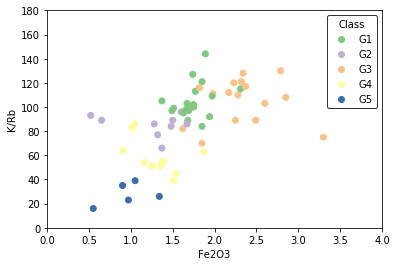

In [582]:
plt.figure()
plt.scatter(df['Fe2O3'],df['K/Rb'], c=c, cmap=cmap)
plt.xlim(0,4)
plt.ylim(0,180)
plt.xlabel('Fe2O3')
plt.ylabel('K/Rb')
plt.legend(handles,
           ["G1","G2","G3","G4","G5"],
           loc="upper right",
           edgecolor = "black",
           title='Class')
plt.show()

##### Fe2O3 vs Rb/Sr

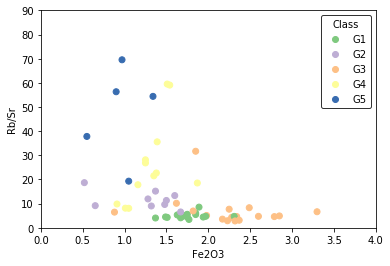

In [583]:
RbSr = df['Rb']/df['Sr']

plt.figure()
plt.scatter(df['Fe2O3'],RbSr, c=c, cmap=cmap)
plt.xlim(0,4)
plt.ylim(0,90)
plt.xlabel('Fe2O3')
plt.ylabel('Rb/Sr')
plt.legend(handles,
           ["G1","G2","G3","G4","G5"],
           loc="upper right",
           edgecolor = "black",
           title='Class')
plt.show()

##### Fe2O3 vs Zr

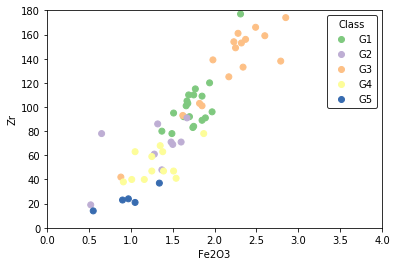

In [584]:
plt.figure()
plt.scatter(df['Fe2O3'],df['Zr'], c=c, cmap=cmap)
plt.xlim(0,4)
plt.ylim(0,180)
plt.xlabel('Fe2O3')
plt.ylabel('Zr')
plt.legend(handles,
           ["G1","G2","G3","G4","G5"],
           loc="upper right",
           edgecolor = "black",
           title='Class')
plt.show()

##### Rb vs Ba

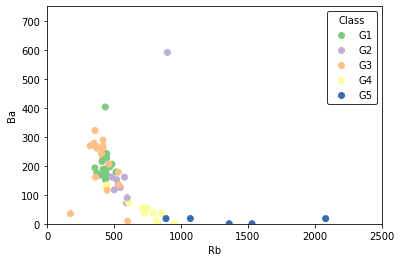

In [585]:
plt.figure()
plt.scatter(df['Rb'],df['Ba'], c=c, cmap=cmap)
plt.xlim(0,2500)
plt.ylim(0,750)
plt.xlabel('Rb')
plt.ylabel('Ba')
plt.legend(handles,
           ["G1","G2","G3","G4","G5"],
           loc="upper right",
           edgecolor = "black",
           title='Class')
plt.show()

##### Zr vs Nb

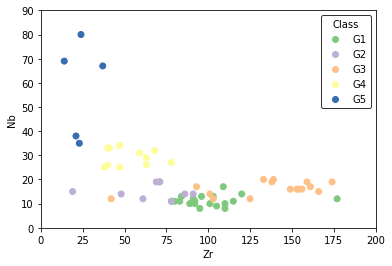

In [586]:
plt.figure()
plt.scatter(df['Zr'],df['Nb'], c=c, cmap=cmap)
plt.xlim(0,200)
plt.ylim(0,90)
plt.xlabel('Zr')
plt.ylabel('Nb')
plt.legend(handles,
           ["G1","G2","G3","G4","G5"],
           loc="upper right",
           edgecolor = "black",
           title='Class')
plt.show()

### IGNORE: Seaborn joint plot - currently not installed (see Section 0)

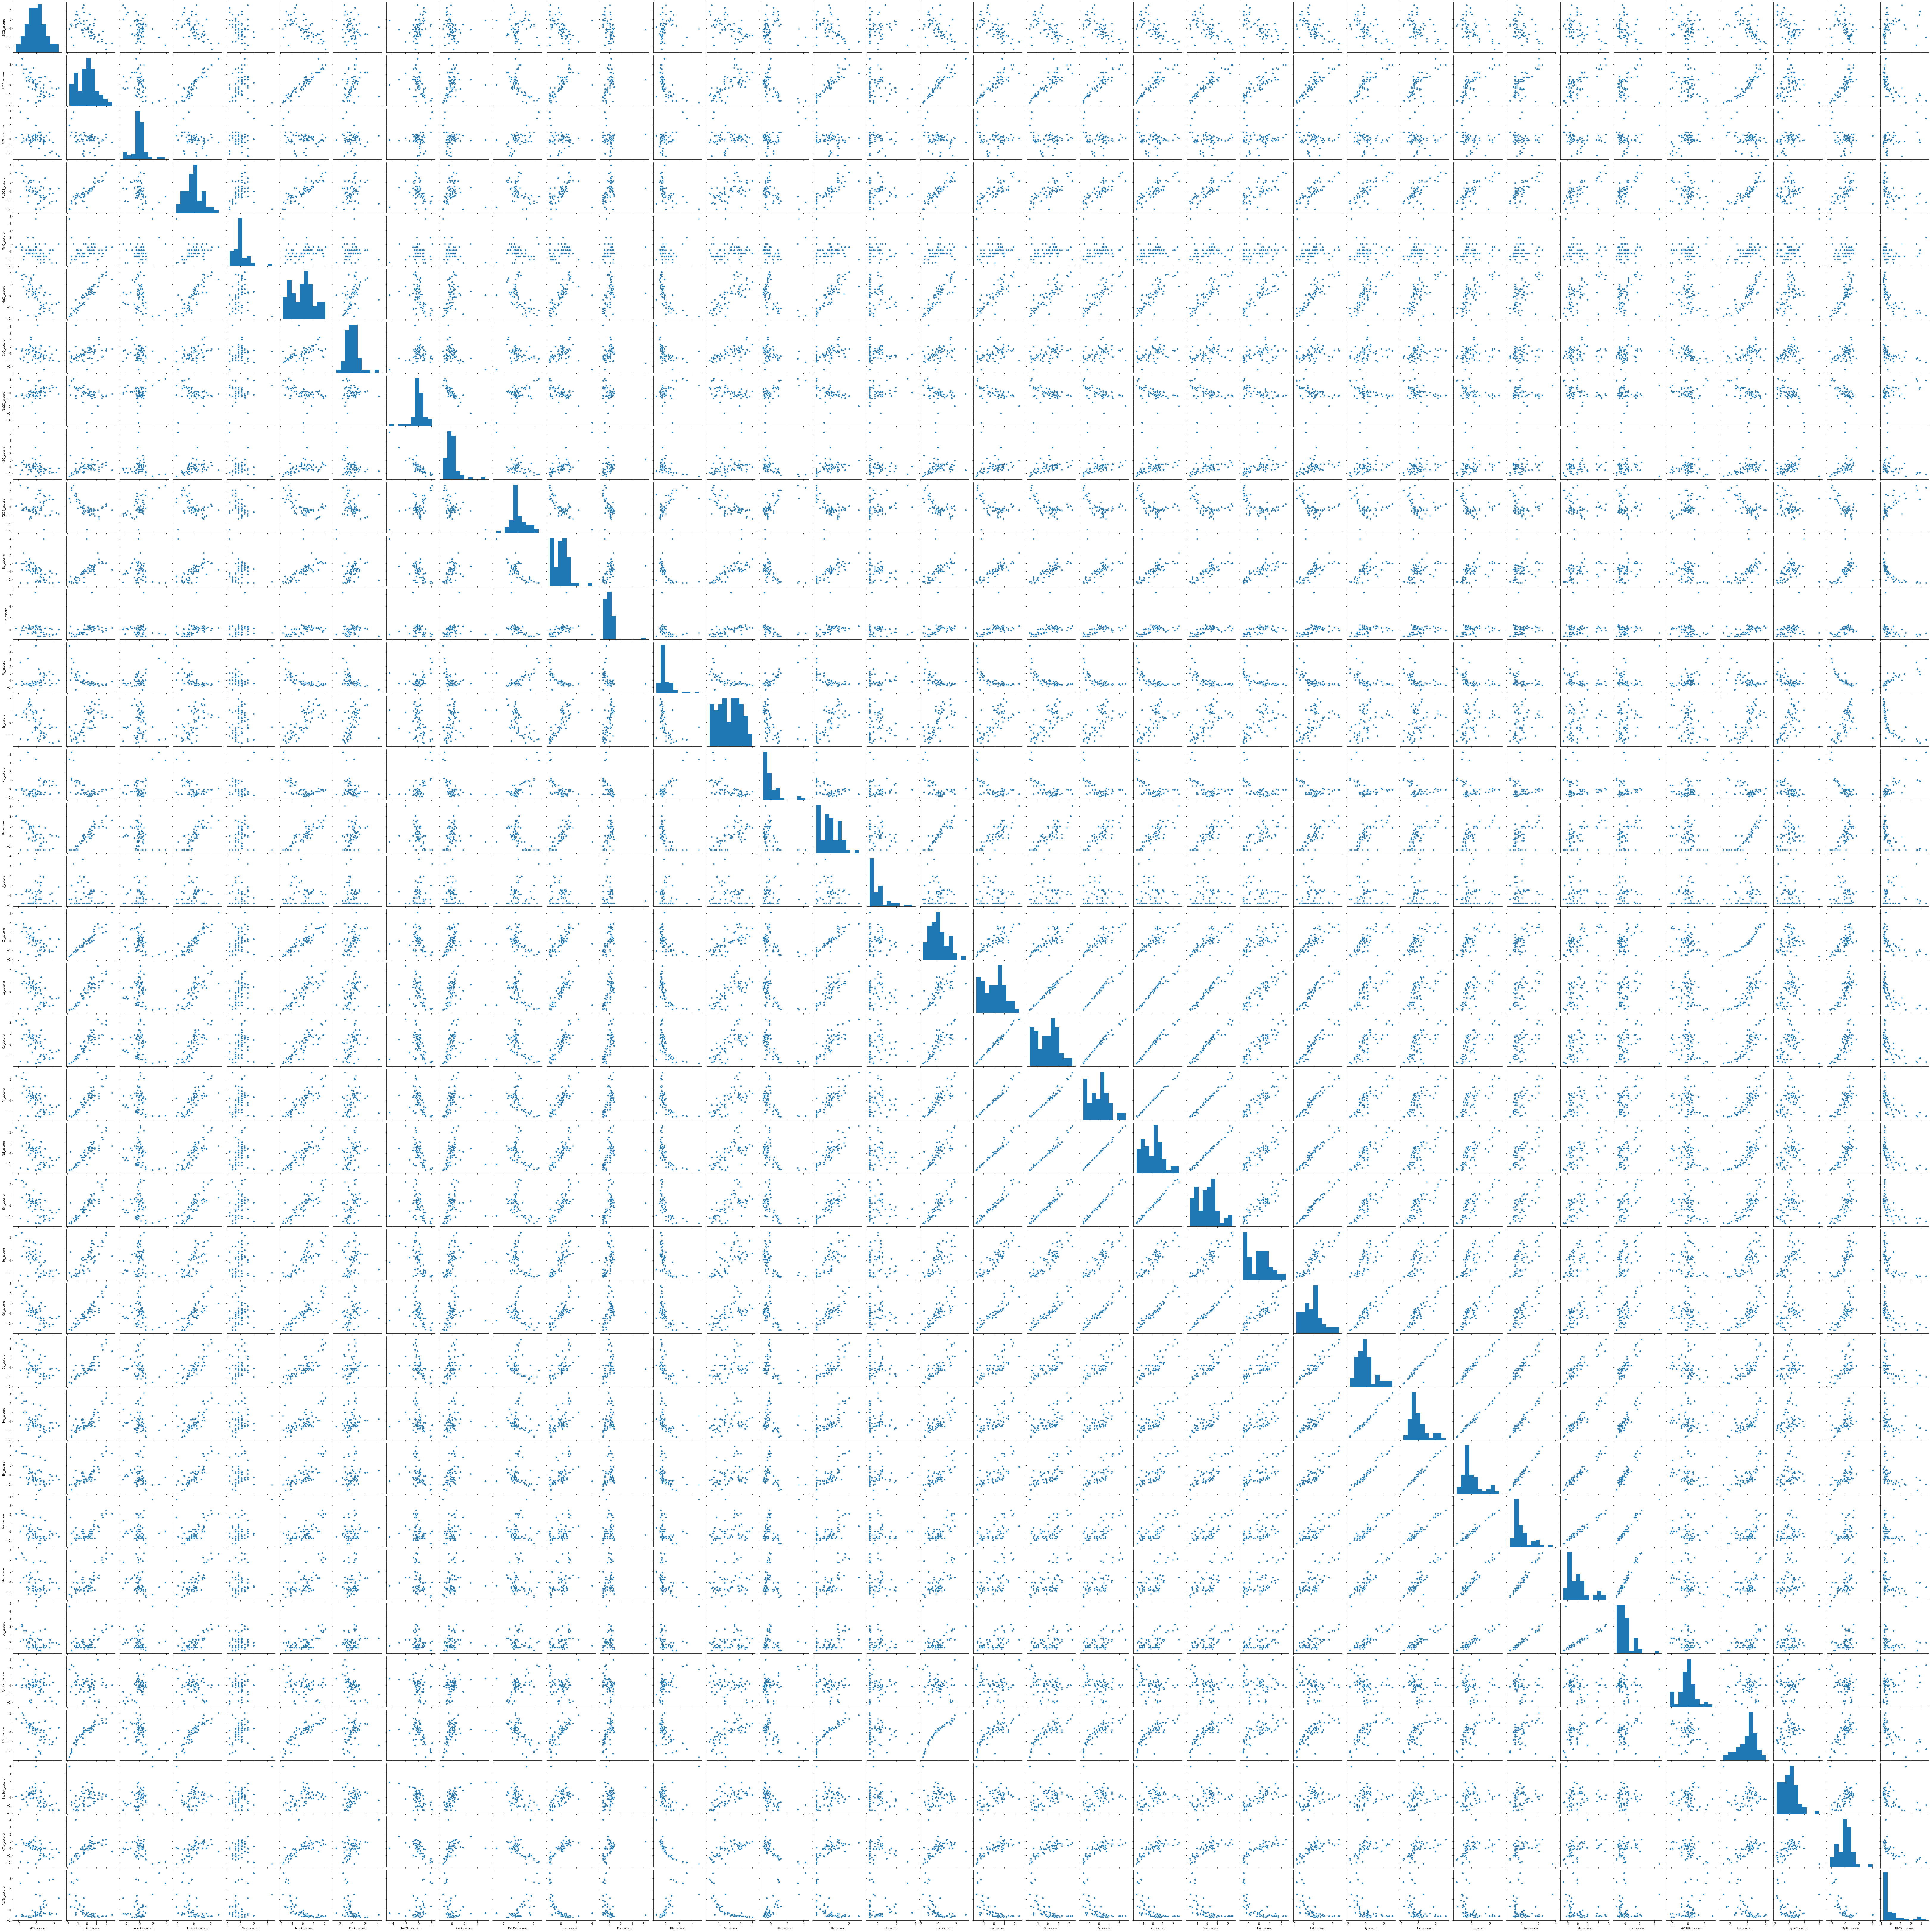

In [423]:
# dfmaj = df.iloc[:, 46:]
# dfmaj
# sns.pairplot(dfmaj)

## Multivariate analysis: PCA

In this section, Principal Component Analysis is used to explore data structure, find common variables and reduce the number of dimensions

### Modelling and variable selection

This section runs the initial model and tries to select the best number of PCs to investigate

In [63]:
# Perform PCA
from sklearn.decomposition import PCA
mdl = PCA(n_components=len(plot_list))
mdl.fit(X=df.iloc[:, 46:])
PCs = mdl.transform(X=df.iloc[:, 46:]) # extract PCs

In [64]:
var_index = np.where(np.cumsum(mdl.explained_variance_ratio_) < 0.96)
print('These are the PCs as cumulative variance {}'.format(np.cumsum(mdl.explained_variance_ratio_[var_index])))

These are the PCs as cumulative variance [0.51455288 0.63795945 0.71722972 0.77819379 0.83038575 0.87166486
 0.89939357 0.92447527 0.94155108 0.95709752]


This plot below comes from this website https://jakevdp.github.io/PythonDataScienceHandbook/05.09-principal-component-analysis.html

Text(0, 0.5, 'cumulative explained variance')

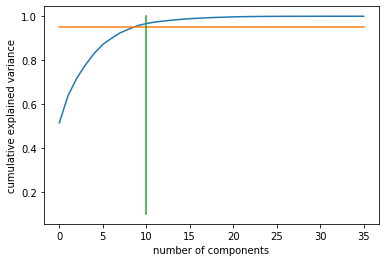

In [65]:
x1 = np.arange(len(mdl.components_))
y1 = np.full(len(mdl.components_), 0.95)

x2 = np.full(len(np.array(var_index)[0]), np.array(var_index)[0][-1]+1) # Because you're recovering an index you need the +1
y2 = np.arange(0.1,1.1,0.1)

plt.plot(np.cumsum(mdl.explained_variance_ratio_))
plt.plot(x1,y1)
plt.plot(x2,y2)
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')

### Exploring the eigenvalues and possible correlations

Here we can look at similar groups of elements/ratios/TZr by pulling out eigenvectors

In [66]:
PCev = pd.DataFrame(mdl.components_, columns=plot_list)
# This reduces the PCs down to the top 11 selected above
PCev = PCev.iloc[:len(var_index[0]),:]

The majors are a good place to start.

There is a quite a lot of diversity here.

In [536]:
PCev.iloc[:,0:10]

,SiO2_zscore,TiO2_zscore,Al2O3_zscore,Fe2O3_zscore,MnO_zscore,MgO_zscore,CaO_zscore,Na2O_zscore,K2O_zscore,P2O5_zscore
0,-0.134868,0.218878,-0.070304,0.188762,0.010670,0.217521,0.074199,-0.119033,0.084776,-0.149474
1,-0.189047,0.003468,0.211134,0.075368,0.221631,-0.018094,-0.027586,0.151420,-0.147501,0.243570
2,-0.206067,-0.047746,0.324583,-0.142420,0.155643,-0.009218,-0.241228,-0.283884,0.352616,-0.056168
3,0.243866,-0.072139,-0.247809,-0.151695,-0.252675,-0.086554,-0.222841,-0.338158,0.382414,-0.103688
4,0.001320,-0.048725,0.034818,-0.167722,0.206337,0.033603,0.477600,0.096569,-0.118166,-0.100434
5,-0.223533,-0.146612,0.356543,-0.187307,-0.387465,-0.018244,0.196234,0.014690,0.058180,0.332411
6,0.188292,-0.101995,-0.092261,-0.065025,0.288871,-0.141904,-0.168827,0.071587,0.003657,-0.144186
7,0.162957,-0.104954,-0.003234,-0.111446,-0.085212,-0.143069,-0.151218,0.179980,-0.116483,0.116977
8,-0.149347,0.073140,0.085422,0.212480,0.172540,0.073165,0.175894,-0.217839,0.047704,0.113679
9,0.178610,-0.071504,-0.148001,0.070604,0.422332,-0.017439,0.173848,-0.289085,0.038657,0.126055


We can also look at those that control temperature. TZr is the crystalisation temperature of Zircon, whereas the concentration of MgO, TiO2 and Fe2O3 are all associated with melting points.

Note how MgO and TiO2 are related. TZr generally tracks these two elements but where it doesn't it follows the Fe2O3 column

In [537]:
PCev[['TZr_zscore','MgO_zscore','TiO2_zscore','Fe2O3_zscore']]

,TZr_zscore,MgO_zscore,TiO2_zscore,Fe2O3_zscore
0,0.201970,0.217521,0.218878,0.188762
1,-0.070918,-0.018094,0.003468,0.075368
2,-0.031886,-0.009218,-0.047746,-0.142420
3,-0.101495,-0.086554,-0.072139,-0.151695
4,-0.180861,0.033603,-0.048725,-0.167722
5,-0.199731,-0.018244,-0.146612,-0.187307
6,-0.080714,-0.141904,-0.101995,-0.065025
7,-0.180006,-0.143069,-0.104954,-0.111446
8,0.142677,0.073165,0.073140,0.212480
9,0.022532,-0.017439,-0.071504,0.070604


We can also look at other combinations, for example here are the REEs.

There doesn't appear to be anything huge to pull out here, but there is a broad correlation of LREEs and HREEs following each other with the exceptions of Eu and Lu that occasionally do their own thing

In [538]:
PCev.iloc[:,18:31]

,La_zscore,Ce_zscore,Pr_zscore,Nd_zscore,Sm_zscore,Eu_zscore,Gd_zscore,Dy_zscore,Ho_zscore,Er_zscore,Tm_zscore,Yb_zscore,Lu_zscore
0,0.217214,0.215045,0.218701,0.220404,0.222278,0.210855,0.221436,0.201976,0.181231,0.184482,0.119750,0.156496,0.086596
1,-0.015238,-0.005637,0.029594,0.031288,0.046442,0.028969,0.077791,0.161606,0.245270,0.206646,0.350485,0.227960,0.358419
2,0.037282,0.018396,0.023608,0.016930,0.008689,0.136864,-0.022702,-0.102007,-0.071384,-0.132774,-0.018077,-0.176998,-0.030094
3,-0.136629,-0.141814,-0.094742,-0.087145,-0.061825,-0.007894,-0.008540,0.144484,0.197025,0.206691,0.200153,0.262425,0.203401
4,-0.056362,-0.077507,-0.097786,-0.106110,-0.094577,0.059267,-0.089687,-0.080086,0.025650,-0.034780,0.178523,-0.028384,0.247494
5,0.050934,0.062625,0.065620,0.065348,0.080529,0.147535,0.098081,0.117123,0.046669,0.093012,-0.074544,0.075142,-0.169204
6,0.075748,0.094402,0.070290,0.049154,0.062391,0.058052,0.061010,0.032798,0.080758,0.013815,0.057748,-0.062040,0.063390
7,0.155012,0.146996,0.153980,0.136457,0.119102,0.128677,0.072183,0.029946,0.037976,0.028117,0.001068,-0.006418,-0.032047
8,-0.181121,-0.212042,-0.184325,-0.165329,-0.136389,-0.099717,-0.091559,0.019932,-0.031571,0.059476,-0.038577,0.157824,-0.014525
9,0.143965,0.164357,0.143805,0.127016,0.111866,0.094634,0.079370,-0.066931,-0.039145,-0.110181,-0.041889,-0.178800,-0.022642


That leaves the \[limited\] trace elements and ratios which are all quite individual

In [539]:
PCev.iloc[:,np.r_[10:18,33:36]]

,Ba_zscore,Pb_zscore,Rb_zscore,Sr_zscore,Nb_zscore,Th_zscore,U_zscore,Zr_zscore,Eu/Eu*_zscore,K/Rb_zscore,Rb/Sr_zscore
0,0.178802,0.101743,-0.159888,0.169241,-0.146405,0.208327,-0.033798,0.205965,0.074908,0.162854,-0.171847
1,-0.124793,-0.087981,0.263904,-0.117964,0.320025,-0.003278,0.042795,0.015160,0.020416,-0.147189,0.210181
2,0.227559,0.165082,0.199206,0.159866,0.034908,-0.024814,-0.063817,-0.082619,0.370399,-0.032538,0.007289
3,0.095894,-0.153683,-0.005016,-0.202715,-0.060825,-0.115643,-0.111641,-0.094553,0.088134,0.095739,0.008699
4,0.007088,0.010334,0.005983,0.207628,-0.030877,-0.110240,-0.163488,-0.085564,0.456280,0.208036,-0.204231
5,-0.055744,-0.148631,-0.196664,-0.054013,-0.083825,-0.153015,0.260193,-0.226833,-0.023075,0.274186,-0.108423
6,-0.170206,0.440806,-0.049867,-0.224311,-0.138624,-0.077719,0.610300,-0.155302,0.109559,0.031470,-0.082282
7,-0.147755,0.415361,-0.077007,-0.061926,-0.062025,-0.082518,-0.655539,-0.159103,-0.027326,0.003036,0.092694
8,-0.164788,0.439159,-0.161294,-0.191887,-0.086483,-0.082158,-0.108017,0.115615,-0.139771,0.410042,0.084824
9,-0.226385,-0.477921,-0.014649,-0.259194,-0.127441,-0.069709,-0.113903,-0.061820,0.024750,0.188948,0.136306


### PC score plotting

This plots the raw score data

#### PC1 and PC2

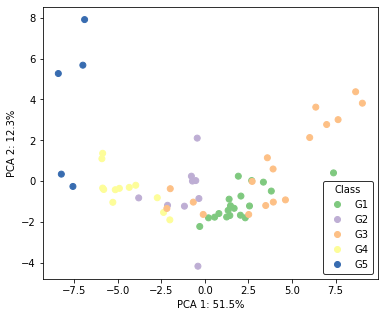

In [67]:
# Visualise pairs of PCs
x = 0 # These are index values so PC1 = 0
y = 1 # These are index values so PC2 = 1
plt.figure(figsize=(6, 5))
plt.scatter(PCs[:, x], PCs[:, y], c=c, cmap=cmap)
plt.xlabel('PCA {}: {:.1f}%'.format(x+1, mdl.explained_variance_ratio_[x]*100))
plt.ylabel('PCA {}: {:.1f}%'.format(y+1, mdl.explained_variance_ratio_[y]*100))
plt.legend(handles,
           ["G1","G2","G3","G4","G5"],
           loc="lower right",
           edgecolor = "black",
           title='Class')
plt.show()

#### PC3 and PC4

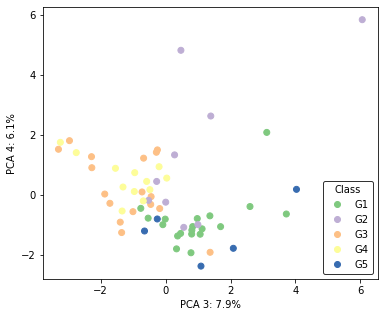

In [588]:
# Visualise pairs of PCs
x = 2 # These are index values so PC1 = 0
y = 3 # These are index values so PC2 = 1
plt.figure(figsize=(6, 5))
plt.scatter(PCs[:, x], PCs[:, y], c=c, cmap=cmap)
plt.xlabel('PCA {}: {:.1f}%'.format(x+1, mdl.explained_variance_ratio_[x]*100))
plt.ylabel('PCA {}: {:.1f}%'.format(y+1, mdl.explained_variance_ratio_[y]*100))
plt.legend(handles,
           ["G1","G2","G3","G4","G5"],
           loc="lower right",
           edgecolor = "black",
           title='Class')
plt.show()

#### PC5 and PC6

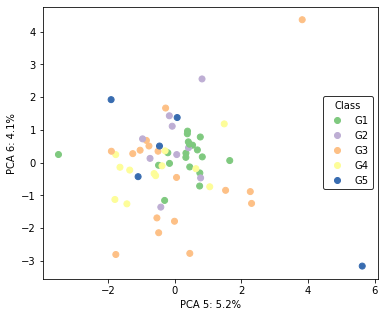

In [589]:
# Visualise pairs of PCs
x = 4 # These are index values so PC1 = 0
y = 5 # These are index values so PC2 = 1
plt.figure(figsize=(6, 5))
plt.scatter(PCs[:, x], PCs[:, y], c=c, cmap=cmap)
plt.xlabel('PCA {}: {:.1f}%'.format(x+1, mdl.explained_variance_ratio_[x]*100))
plt.ylabel('PCA {}: {:.1f}%'.format(y+1, mdl.explained_variance_ratio_[y]*100))
plt.legend(handles,
           ["G1","G2","G3","G4","G5"],
           loc="right",
           edgecolor = "black",
           title='Class')
plt.show()

#### PC7 and PC8

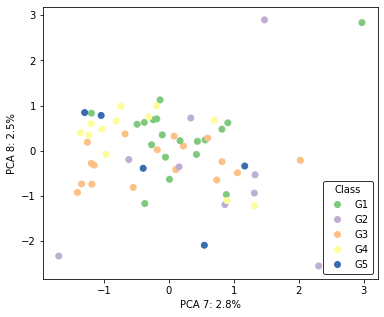

In [590]:
# Visualise pairs of PCs
x = 6 # These are index values so PC1 = 0
y = 7 # These are index values so PC2 = 1
plt.figure(figsize=(6, 5))
plt.scatter(PCs[:, x], PCs[:, y], c=c, cmap=cmap)
plt.xlabel('PCA {}: {:.1f}%'.format(x+1, mdl.explained_variance_ratio_[x]*100))
plt.ylabel('PCA {}: {:.1f}%'.format(y+1, mdl.explained_variance_ratio_[y]*100))
plt.legend(handles,
           ["G1","G2","G3","G4","G5"],
           loc="lower right",
           edgecolor = "black",
           title='Class')
plt.show()

#### PC9 and PC10

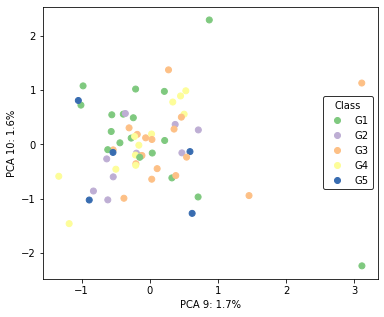

In [591]:
# Visualise pairs of PCs
x = 8 # These are index values so PC1 = 0
y = 9 # These are index values so PC2 = 1
plt.figure(figsize=(6, 5))
plt.scatter(PCs[:, x], PCs[:, y], c=c, cmap=cmap)
plt.xlabel('PCA {}: {:.1f}%'.format(x+1, mdl.explained_variance_ratio_[x]*100))
plt.ylabel('PCA {}: {:.1f}%'.format(y+1, mdl.explained_variance_ratio_[y]*100))
plt.legend(handles,
           ["G1","G2","G3","G4","G5"],
           loc="right",
           edgecolor = "black",
           title='Class')
plt.show()

### PCA biplot function

This function plots a biplot where _normalised_ scores are plotted and the eigenvectors are overlain

In [72]:
def biplot(score,coeff,labels=None,xlab=1,ylab=2, c=None, cmap=None):
    xs = score[:,0]
    ys = score[:,1]
    n = coeff.shape[0]
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())
    plt.scatter(xs * scalex,ys * scaley, c = c, cmap=cmap)
    for i in range(n):
        plt.arrow(0, 0, coeff[i,0], coeff[i,1],color = 'r',alpha = 0.5)
        if labels is None:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, "Var"+str(i+1), color = 'g', ha = 'center', va = 'center',alpha = 0.5)
        else:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, labels[i], color = 'g', ha = 'center', va = 'center',alpha = 0.5)
    plt.xlim(-1,1)
    plt.ylim(-1,1)
    plt.xlabel("PC{}".format(xlab))
    plt.ylabel("PC{}".format(ylab))
    plt.grid()

### Plot biplots calling two PCs at a time

#### Set additional params

In [73]:
# Labels - dropped '_z-score' from label because too long
cols = list(df.columns)
varlabs = cols[8:46]
rm = ['LOI', 'Total']
for i in rm:
    varlabs.remove(i)

#### Individual bivariate component plots

##### PC1 and PC2

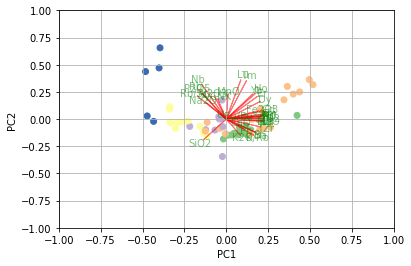

In [74]:
biplot(PCs[:,0:2],np.transpose(mdl.components_[0:2, :]), labels=varlabs, xlab=1,ylab=2, c=c, cmap=cmap)
#plt.savefig("biplot12.svg", format="svg")

##### PC3 and PC4

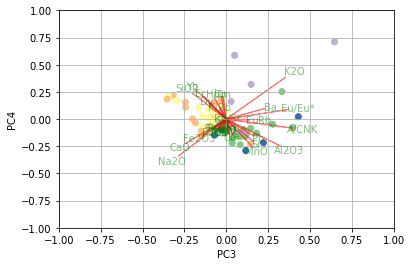

In [594]:
biplot(PCs[:,2:4],np.transpose(mdl.components_[2:4, :]), labels=varlabs, xlab=3,ylab=4, c=c, cmap=cmap)

##### PC5 and PC6

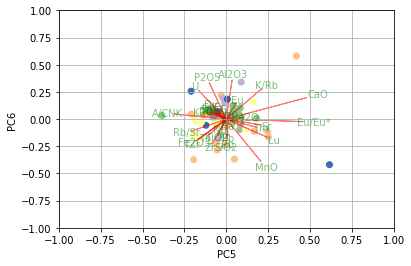

In [595]:
biplot(PCs[:,4:6],np.transpose(mdl.components_[4:6, :]), labels=varlabs, xlab=5,ylab=6, c=c, cmap=cmap)

##### PC7 and PC8

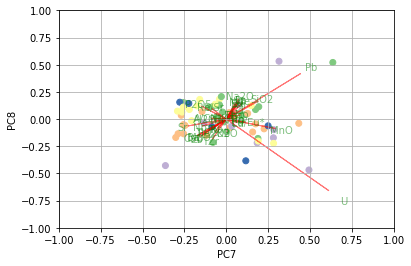

In [596]:
biplot(PCs[:,6:8],np.transpose(mdl.components_[6:8, :]), labels=varlabs, xlab=7,ylab=8, c=c, cmap=cmap)

##### PC9 and PC10

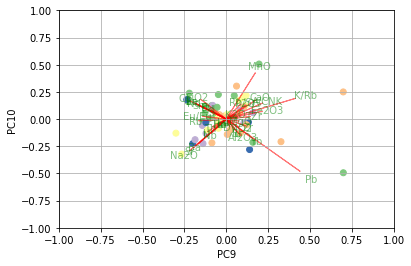

In [597]:
biplot(PCs[:,8:10],np.transpose(mdl.components_[8:10, :]), labels=varlabs, xlab=9,ylab=10, c=c, cmap=cmap)

#### All biplots for top 10 PCs

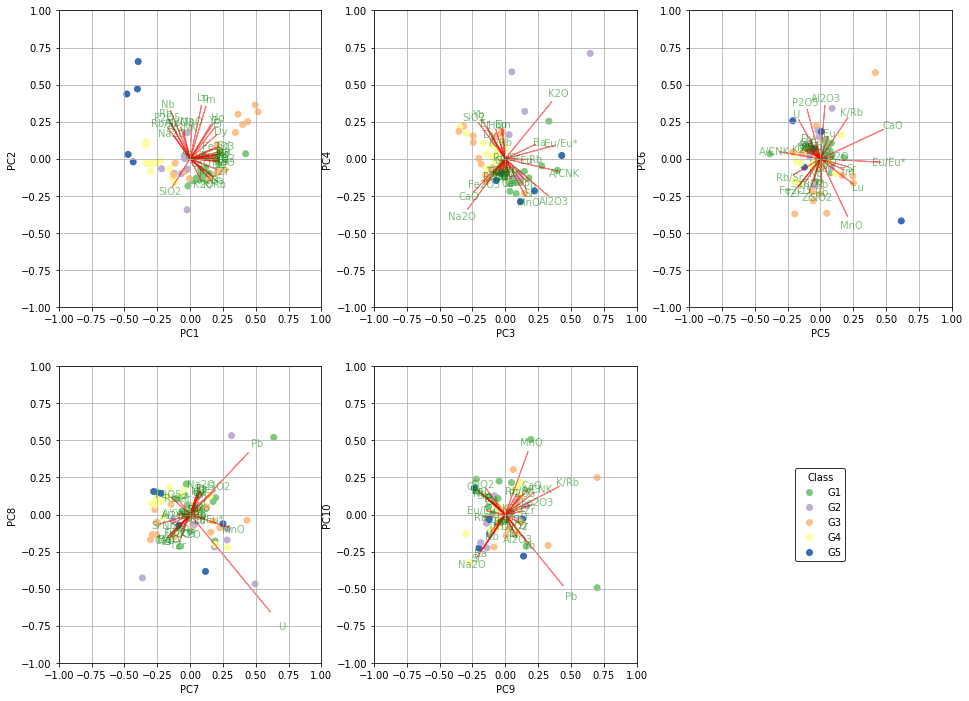

In [598]:
fig, axes = plt.subplots(2,3, figsize = [16,12])
plt.sca(axes[0,0])
axes[0,0] = biplot(PCs[:,0:2],np.transpose(mdl.components_[0:2, :]), labels=varlabs, xlab=1,ylab=2, c=c, cmap=cmap)
plt.sca(axes[0,1])
axes[0,1] = biplot(PCs[:,2:4],np.transpose(mdl.components_[2:4, :]), labels=varlabs, xlab=3,ylab=4, c=c, cmap=cmap)
plt.sca(axes[0,2])
axes[0,2] = biplot(PCs[:,4:6],np.transpose(mdl.components_[4:6, :]), labels=varlabs, xlab=5,ylab=6, c=c, cmap=cmap)
plt.sca(axes[1,0])
axes[1,0] = biplot(PCs[:,6:8],np.transpose(mdl.components_[6:8, :]), labels=varlabs, xlab=7,ylab=8, c=c, cmap=cmap)
plt.sca(axes[1,1])
axes[1,1] = biplot(PCs[:,8:10],np.transpose(mdl.components_[8:10, :]), labels=varlabs, xlab=9,ylab=10, c=c, cmap=cmap)
plt.sca(axes[1,2])
lastSubplot = axes[1,2]
lastSubplot.set_frame_on(False)
lastSubplot.get_xaxis().set_visible(False)
lastSubplot.get_yaxis().set_visible(False)
lastSubplot.legend(handles,
           ["G1","G2","G3","G4","G5"],
           loc="center",
           edgecolor = "black",
           title='Class')

## Multivariate analysis: t-SNE

The t-SNE algorithm is more powerful than the PCA technique because it preserves local structure in the data and can capture non-linear relationships much more effectively than PCA. The local structure is controlled by the hyperparameter `perplexity`. Increasing this value leads to a greater search radius to define 'local' stucture - ultimately capturing greater and greater 'global' stucture in the dataset.

The output is two embeddings (you can create three but we stick with two here). These embeddings represent a new data structure that is not a true Euclidean transformation. These embeddings capture local similarities but do not preserve data density. To better understand the data structure in these embeddings one can overlay original data values as a colour ramp.

### t-SNE models (can be ignored)

The t-SNE modelling code is really simple! Four lines and you're there but it does require careful interrogation as can be seen in Section 1.3.2.

In [50]:
# Perplexity flexing
p1 = int(len(df.iloc[:, 46])/3)
p2 = int(len(df.iloc[:, 46])**0.5)
# Compute t-SNE embedding
from sklearn.manifold import TSNE
np.random.seed(250489) # to reproduce results
mdlT1 = TSNE(n_components=2, perplexity=12, n_iter = 5000, learning_rate=30)
mdlT2 = TSNE(n_components=2, perplexity=p2, n_iter = 5000, learning_rate=200)
mdlT3 = TSNE(n_components=2, perplexity=p2, n_iter = 5000, learning_rate=30)
mdlT4 = TSNE(n_components=2, perplexity=p2, n_iter = 5000, learning_rate=30, early_exaggeration=24)
T1embedding = mdlT1.fit_transform(X=df.iloc[:, 46:])
T2embedding = mdlT2.fit_transform(X=df.iloc[:, 46:])
T3embedding = mdlT3.fit_transform(X=df.iloc[:, 46:])
T4embedding = mdlT4.fit_transform(X=df.iloc[:, 46:])
mdlT1,mdlT2,mdlT3, mdlT4

(TSNE(angle=0.5, early_exaggeration=12.0, init='random', learning_rate=30,
      method='barnes_hut', metric='euclidean', min_grad_norm=1e-07,
      n_components=2, n_iter=5000, n_iter_without_progress=300, n_jobs=None,
      perplexity=12, random_state=None, verbose=0),
 TSNE(angle=0.5, early_exaggeration=12.0, init='random', learning_rate=200,
      method='barnes_hut', metric='euclidean', min_grad_norm=1e-07,
      n_components=2, n_iter=5000, n_iter_without_progress=300, n_jobs=None,
      perplexity=7, random_state=None, verbose=0),
 TSNE(angle=0.5, early_exaggeration=12.0, init='random', learning_rate=30,
      method='barnes_hut', metric='euclidean', min_grad_norm=1e-07,
      n_components=2, n_iter=5000, n_iter_without_progress=300, n_jobs=None,
      perplexity=7, random_state=None, verbose=0),
 TSNE(angle=0.5, early_exaggeration=24, init='random', learning_rate=30,
      method='barnes_hut', metric='euclidean', min_grad_norm=1e-07,
      n_components=2, n_iter=5000, n_iter_wi

### t-SNE optimisation (can be ignored)

This is really me playing with the t-SNE method to understand it better but it may have some merit for a future paper

#### Perplexity testing (univariate)

In [345]:
d = df.iloc[:, 46:]
p = np.arange(2, 102, 2).tolist()
lr = 200
def perp_testing(data,perp,lrate):
    kl = []
    it = []
    np.random.seed(250489) # to reproduce results
    for item in perp:
        mdl = TSNE(n_components=2, perplexity=item, n_iter = 5000, learning_rate=lrate)
        e = mdl.fit_transform(X=data)
        k = mdl.kl_divergence_
        n_it = mdl.n_iter_
        kl.append(k)
        it.append(n_it)
    return kl,it
    
perp_kl, perp_it = perp_testing(d,p,lr)

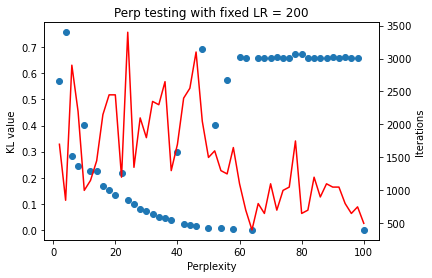

In [353]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.scatter(p, perp_kl)
ax2.plot(p, perp_it, c='r')
plt.title('Perp testing with fixed LR = 200')
ax1.set_xlabel('Perplexity')
ax1.set_ylabel('KL value')
ax2.set_ylabel('Iterations')
plt.show()

#### Learning Rate testing (univariate)

In [344]:
d = df.iloc[:, 46:]
p = 7
lr = np.arange(10, 500, 5).tolist()
def lr_testing(data,perp,lrate):
    kl = [] 
    it = []
    np.random.seed(250489) # to reproduce results
    for item in lrate:
        mdl = TSNE(n_components=2, perplexity=perp, n_iter = 5000, learning_rate=item)
        e = mdl.fit_transform(X=data)
        k = mdl.kl_divergence_
        n_it = mdl.n_iter_
        kl.append(k)
        it.append(n_it)
    return kl,it
    
lr_kl, lr_it = lr_testing(d,p,lr)

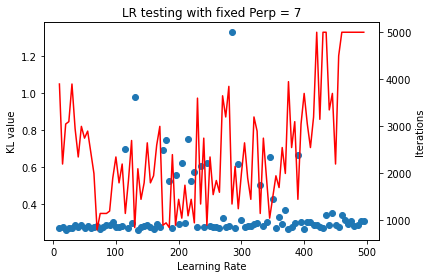

In [351]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.scatter(lr, lr_kl)
ax2.plot(lr, lr_it, c='r')
plt.title('LR testing with fixed Perp = 7')
ax1.set_xlabel('Learning Rate')
ax1.set_ylabel('KL value')
ax2.set_ylabel('Iterations')
plt.show()

#### Early Exaggeration testing (univariate)

In [342]:
d = df.iloc[:, 46:]
p = int(len(df.iloc[:, 46])**0.5)
lr = 30
ee = np.arange(1, 101, 1).tolist()
def ee_testing(data,perp,lrate,ee):
    kl = [] 
    it = []
    np.random.seed(250489) # to reproduce results
    for item in ee:
        mdl = TSNE(n_components=2, perplexity=perp, n_iter = 5000, learning_rate=lrate, early_exaggeration=item)
        e = mdl.fit_transform(X=data)
        k = mdl.kl_divergence_
        n_it = mdl.n_iter_
        kl.append(k)
        it.append(n_it)
    return kl,it
    
ee_kl, ee_it = ee_testing(d,p,lr,ee)

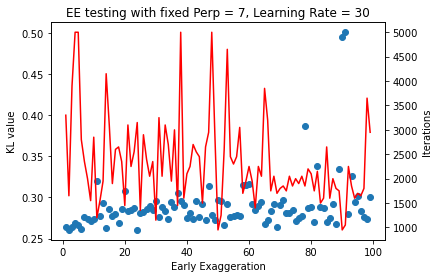

In [343]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.scatter(ee, ee_kl)
ax2.plot(ee, ee_it, c='r')
plt.title('EE testing with fixed Perp = 7, Learning Rate = 30')
ax1.set_xlabel('Early Exaggeration')
ax1.set_ylabel('KL value')
ax2.set_ylabel('Iterations')
plt.show()

#### Perplexity and Learning Rate testing (bivariate)

In [238]:
p = np.arange(2, 102, 2).tolist()
d = df.iloc[:, 46:]
lr = np.arange(10, 505, 5).tolist()
def tsne_testing(data,perp,lrate):
    m = (len(perp),len(lrate))
    kl = np.zeros(m)
    it = np.zeros(m)
    np.random.seed(250489) # to reproduce results
    for p in perp:
        for l in lrate:
            mdl = TSNE(n_components=2, perplexity=p, n_iter = 5000, learning_rate=l)
            e = mdl.fit_transform(X=data)
            k = mdl.kl_divergence_
            n_it = mdl.n_iter_
            pos = pos = [int(len(lr)*perp.index(p)+(lrate.index(l)-1))]
            np.put(kl,pos,k)
            np.put(it,pos,n_it)
    return kl,it
    
tsne_kl, tsne_it = tsne_testing(d,p,lr)

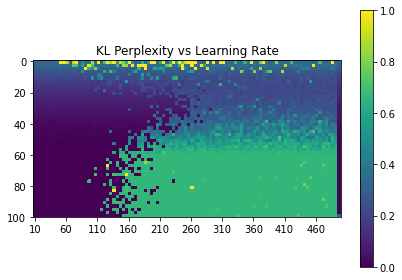

In [300]:
fig, ax = plt.subplots()
im = ax.imshow(tsne_kl)
#
ax.set_xticks(np.arange(0,99,10))
ax.set_yticks(np.arange(0,98,10))
# ... and label them with the respective list entries
ax.set_xticklabels(np.arange(10,(len(lr)+1)*10,50))
ax.set_yticklabels(np.arange(0,(len(lr)+1)*10,20))
# 
ax.set_title("KL Perplexity vs Learning Rate")
pcm = ax.pcolormesh(tsne_kl, cmap='viridis')
pcm.set_clim(0,1)
fig.colorbar(pcm, ax=ax)
ax.set_xlabel = 'Learning Rate'
ax.set_ylabel = 'Perplexity'
fig.tight_layout()
plt.show()

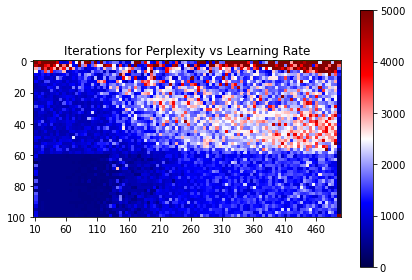

In [301]:
fig, ax = plt.subplots()
im = ax.imshow(tsne_it)
#
ax.set_xticks(np.arange(0,99,10))
ax.set_yticks(np.arange(0,98,10))
# ... and label them with the respective list entries
ax.set_xticklabels(np.arange(10,(len(lr)+1)*10,50))
ax.set_yticklabels(np.arange(0,(len(lr)+1)*10,20))
# 
ax.set_title("Iterations for Perplexity vs Learning Rate")
pcm = ax.pcolormesh(tsne_it, cmap='seismic')
pcm.set_clim(0,5000)
fig.colorbar(pcm, ax=ax)
ax.set_xlabel = 'Learning Rate'
ax.set_ylabel = 'Perplexity'
fig.tight_layout()
plt.show()

### t-SNE plotting

This plots up various t-SNE models either as single or double plots for comparison of the structure.

All the models have taken the same input data - all the geochemical variables - but have been tuned by slightly different hyperparameters. Overall, model `mdlT3` and the associated `T3embedding` data are preferred. This is due to the more clear groupings - admittedly this is a bit of a subjective decision but it is backed up by the lower KL Divergence value.

KL Divergence is how much the t-SNE transformation is different to the original data structure. It is a measure of lost information. t-SNE models attempt to minimise the KL divergence (e.g. a KLD = 0 means it is a perfect replication). It is not a measure of distance from the original data structure, it is more abstract than that.

#### Single t-SNE plot

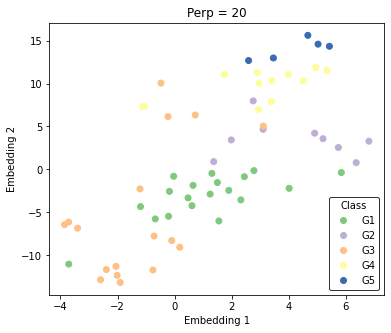

In [313]:
x = 0 # These are index values to the embedding
y = 1 # These are index values to the embedding
plt.figure(figsize=(6, 5))
plt.scatter(T1embedding[:, x], T1embedding[:, y], c=c, cmap=cmap)
plt.xlabel('Embedding {}'.format(x+1))
plt.ylabel('Embedding {}'.format(y+1))
plt.title('Perp = {}'.format(p1))
plt.legend(handles,
           ["G1","G2","G3","G4","G5"],
           loc="lower right",
           edgecolor = "black",
           title='Class')
plt.show()

#### Double t-SNE plot

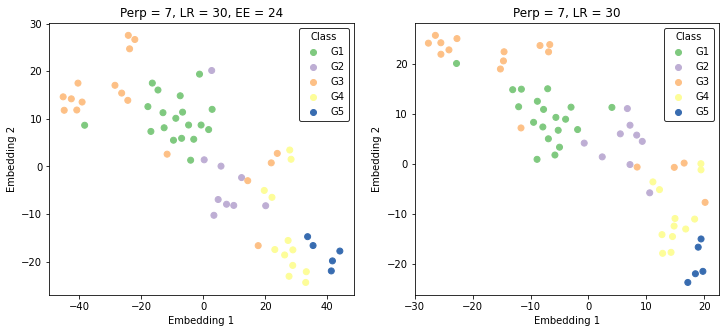

(0.30163609981536865, 0.2656542956829071)

In [13]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12, 5))
scatter1 = ax1.scatter(T4embedding[:, 0], 
                       T4embedding[:, 1], 
                       c = c, 
                       cmap = cmap)
scatter2 = ax2.scatter(T3embedding[:, 0], 
                       T3embedding[:, 1], 
                       c = c, 
                       cmap = cmap)
ax1.set_xlabel('Embedding 1')
ax1.set_ylabel('Embedding 2')
ax2.set_xlabel('Embedding 1')
ax2.set_ylabel('Embedding 2')
ax1.title.set_text(MDL4: 'Perp = {}, LR = {}, EE = {}'.format(mdlT4.perplexity,mdlT4.learning_rate,mdlT4.early_exaggeration))
ax2.title.set_text(MDL3: 'Perp = {}, LR = {}'.format(mdlT3.perplexity,mdlT3.learning_rate,mdlT3.early_exaggeration))
legend1 = ax1.legend(handles,
                     ["G1","G2","G3","G4","G5"], 
                     loc='upper right',
                     edgecolor = "black",
                     title='Class')
legend2 = ax2.legend(handles,
                     ["G1","G2","G3","G4","G5"], 
                     loc='upper right',
                     edgecolor = "black",
                     title='Class')
plt.show()
mdlT4.kl_divergence_,mdlT3.kl_divergence_

### t-SNE visualisation

This is an important step to understand where the information in the t-SNE plot is held and how it corresponds to different granite types. The plot on the left shows granite types, the plot on the right can be tweaked to highlight different elements. Phosphate is a good one to start but you can check the different elements by twiddling the top two lines - the rest should stay the same!

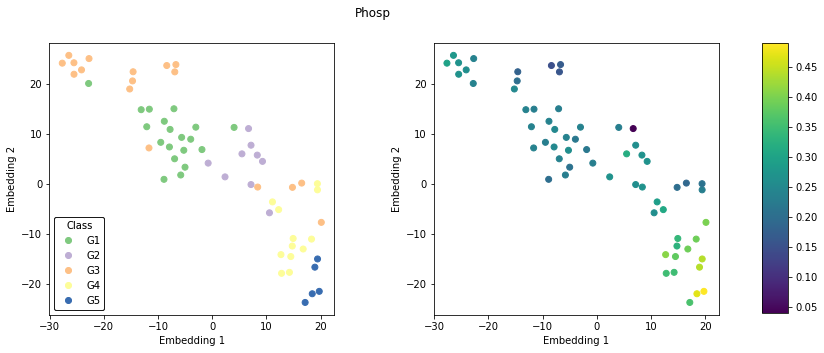

In [14]:
# Set what you're interested in
var_map = df.P2O5 # This is the column to map concentrations in t-SNE, change to df.P2O5 for example
sp_title = 'Phosp' # This is the overall plot title for the element of interest
# Visualise the first two embeddings
## Plot
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12, 5))
scatter1 = ax1.scatter(T3embedding[:, 0], 
                       T3embedding[:, 1], 
                       c = c, 
                       cmap = cmap)
scatter2 = ax2.scatter(T3embedding[:, 0], T3embedding[:, 1], c = var_map, cmap = 'viridis')
ax1.set_xlabel('Embedding 1')
ax1.set_ylabel('Embedding 2')
ax2.set_xlabel('Embedding 1')
ax2.set_ylabel('Embedding 2')
im = plt.gca().get_children()[0]
cax = fig.add_axes([0.95,0.13,0.03,0.75]) 
fig.colorbar(im, cax=cax)
fig.suptitle(sp_title)
# Legend for plot 1
legend1 = ax1.legend(handles,
                     ["G1","G2","G3","G4","G5"], 
                     loc = 'lower left',
                     edgecolor = "black",
                     title='Class')
legend1.edgecolor = 'black'
ax1.add_artist(legend1)
plt.subplots_adjust(wspace=0.35)
plt.show()

# Compositional data analysis testing

Compositional Data Analysis, or CoDa as it is commonly referred to in the literature, is a powerful tool for unlocking datasets where the variables associated with each sample sum to 100 or 1 or some unity value. A good example is geochemistry where values sum to 100 as percentages, although care needs to be taken for trace elements that are recorded as *ppm*. Where values sum to a unity value, standard statistics are (technically) inappropriate because the components that make up each sample are relative. For example, an increase in Na2O may result in a decrease in K2O. This could wholly be accounted by K2O or have an effect on other variables within the sample. Therefore, granite types defined as being 'higher in Na2O' are inherently also lower in (some) other elements. This is referred to as the 'closure problem'. There's a whole bunch of maths behind it all but the way around it is using transforms such as the centered log ratio (*clr*) and isometric log ratio (*ilr*). The *clr* preserves the input variables but sums to zero and so can cause issues with further transformations of the data such as PCA, for example. The *ilr* preserves N-1 variables and is thereofre more difficult to interpret and visualise but is more mathematically correct. There are back transformations for these processes so you can kind of relate them back to the raw data which one is most likely familiar with.

Here, I thought it was worth exploring the effect of using CoDa on the granite data. We start with some data shuffling, such as removing the 'Total' column (this is now implicit), and testing the effects of what can go wrong when doing the data prep - all lessons learned as I did this!

## Initial testing

This is really getting to grips with the CoDa method and how it can transform data - both when you get it right and get it wrong!

### Data shuffling

This is for making a few slightly different dataframes

#### 2.1.1.1. Quick transform using clr on original values

In [7]:
# Create new df with just the original raw analyses (for now I've abanndoned the locality data etc)
df2 = df.iloc[:,8:41]
df2 = df2.drop('Total',axis=1)
df2.columns

Index(['SiO2', 'TiO2', 'Al2O3', 'Fe2O3', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O',
       'P2O5', 'LOI', 'Ba', 'Pb', 'Rb', 'Sr', 'Nb', 'Th', 'U', 'Zr', 'La',
       'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu'],
      dtype='object')

In [8]:
# This needs to be a numpy array for the transformation
cols = list(df2.columns)
np2 = df2.to_numpy()

In [16]:
# Import the required bits and pieces
from skbio.stats import composition as skbc

In [10]:
# Now we will take care of any zeros using the first line, check for closure on second line, and the transfrom to clr
npm = skbc.multiplicative_replacement(np2)
npm = skbc.closure(npm)
npc = skbc.clr(npm)
# Let's check that and convert back to a dataframe
npc.shape
df2c = pd.DataFrame(data=npc)
df2c.columns = df2.columns

So all of that created a dataframe where we filled in zero values with a tiny new value and then checked the closure problem before transforming using the *clr* function. What we didn't do is account for different units! 

#### 2.1.1.2. Now addressing the units

In this iteration, I'll change the *ppm* data to percentages (%):

In [11]:
# Create another df and drop the 'Total' column
df3 = df.iloc[:,8:41]
df3 = df3.drop('Total',axis=1)
# Check where the ppm variables start
cols = list(df3.columns)
cols = cols[11:]
# This loops through and creates a new col with ppm converted to %
for col in cols:
    col_pc = col + '_pc'
    df3[col_pc] = (df3[col]/10000) # 10000 is the factor required to make a %
# And this bit removes the old cols because they're redundant now
rm = df3.columns[10:31]
for i in rm:
    df3 = df3.drop(i, axis=1)
# And finally convert to numpy
np3 = df3.to_numpy()

In [12]:
# Now we will take care of any zeros using the first line, check for closure on second line, and the transfrom to clr
npm = skbc.multiplicative_replacement(np3)
npm = skbc.closure(npm)
npc = skbc.clr(npm)
# Let's check that and convert back to a dataframe
npc.shape
df3c = pd.DataFrame(data=npc)
df3c.columns = df3.columns

In [13]:
# And this is just to check that all the columns have the right variables and one hasn't been accidentally dropped (yes, I did have an issue there)
print(df2.columns, df2c.columns, df3c.columns)

Index(['SiO2', 'TiO2', 'Al2O3', 'Fe2O3', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O',
       'P2O5', 'LOI', 'Ba', 'Pb', 'Rb', 'Sr', 'Nb', 'Th', 'U', 'Zr', 'La',
       'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu'],
      dtype='object') Index(['SiO2', 'TiO2', 'Al2O3', 'Fe2O3', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O',
       'P2O5', 'LOI', 'Ba', 'Pb', 'Rb', 'Sr', 'Nb', 'Th', 'U', 'Zr', 'La',
       'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu'],
      dtype='object') Index(['SiO2', 'TiO2', 'Al2O3', 'Fe2O3', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O',
       'P2O5', 'Lu', 'Ba_pc', 'Pb_pc', 'Rb_pc', 'Sr_pc', 'Nb_pc', 'Th_pc',
       'U_pc', 'Zr_pc', 'La_pc', 'Ce_pc', 'Pr_pc', 'Nd_pc', 'Sm_pc', 'Eu_pc',
       'Gd_pc', 'Dy_pc', 'Ho_pc', 'Er_pc', 'Tm_pc', 'Yb_pc', 'Lu_pc'],
      dtype='object')


### Color pallette

Below is a color palette for plotting up the G1-5 groups

In [21]:
from palettable.colorbrewer.qualitative import Accent_5
c = df['G']
cmap = Accent_5.mpl_colormap
handles, labels = scatter1.legend_elements()

### Transform comparison

OK, so now lets see the effect of these permutations of the data. We will plot below the raw data from Dataframe 2 ```df2```, the *clr* data from Dataframe 2 ```df2c``` and the *clr* data of Dataframe 3 ```df3c``` where the units have been corrected.

Let's use the Nb/Zr plot from Simons et al. (2016) to illustrate this point:

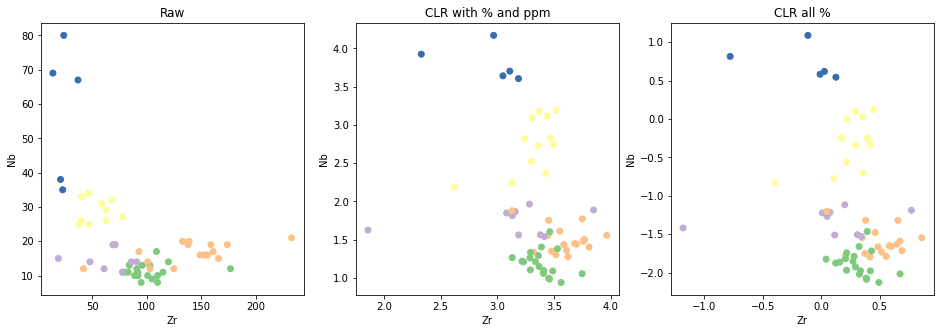

In [16]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3,figsize=(16, 5))
scatter1 = ax1.scatter(df2.iloc[:, 18], 
                       df2.iloc[:, 15], 
                       c = c, 
                       cmap = cmap)
scatter2 = ax2.scatter(df2c.iloc[:, 18], 
                       df2c.iloc[:, 15], 
                       c = c, 
                       cmap = cmap)
scatter3 = ax3.scatter(df3c.iloc[:, 18], 
                       df3c.iloc[:, 15], 
                       c = c, 
                       cmap = cmap)
ax1.set_xlabel('Zr')
ax1.set_ylabel('Nb')
ax2.set_xlabel('Zr')
ax2.set_ylabel('Nb')
ax3.set_xlabel('Zr')
ax3.set_ylabel('Nb')
ax1.title.set_text('Raw')
ax2.title.set_text('CLR with % and ppm')
ax3.title.set_text('CLR all %')

### Exploring the *ilr* transform and data analysis

Now, one can also plot the *ilr* which is usable for doing further data transformations. So here we go, this is simply creating a new dataframe where Dataframe 3 has been transformed using the *ilr* transform ```df3i```

In [18]:
npm = skbc.multiplicative_replacement(np3)
npm = skbc.closure(npm)
npi = skbc.ilr(npm)
npi.shape
df3i = pd.DataFrame(data=npi)
#df3i.columns = df3.columns

#### t-SNE on *ilr* data

Right, now lets do some data transformations on the *ilr* data using ```df3i```

In [19]:
# Compute t-SNE embedding
from sklearn.manifold import TSNE
np.random.seed(250489) # to reproduce results
mdlTCi1 = TSNE(n_components=2, perplexity=8, n_iter=5000, learning_rate=30, early_exaggeration=8)
TCi1embedding = mdlTCi1.fit_transform(X=df3i)

I'm skipping out optimising the t-SNE model here because it's not that important - well, OK, I'm lazy - but we can visualise this and see that overall this isn't too bad and we increase the separability of G1 and G3. Unfortuantely we seem to have muddied the waters when it comes to G2, G4 and G5 compared to back when we used raw data! Why could this be...?

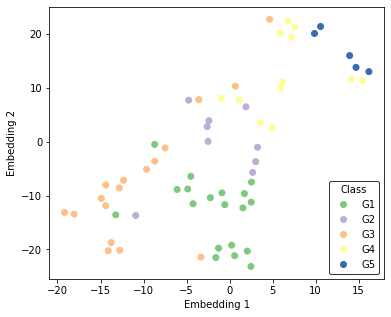

(0.2475372850894928, 2049)

In [22]:
x = 0 # These are index values to the embedding
y = 1 # These are index values to the embedding
plt.figure(figsize=(6, 5))
plt.scatter(TCi1embedding[:, x], TCi1embedding[:, y], c=c, cmap=cmap)
plt.xlabel('Embedding {}'.format(x+1))
plt.ylabel('Embedding {}'.format(y+1))
# plt.title('Perp = 7')
plt.legend(handles,
           ["G1","G2","G3","G4","G5"],
           loc="lower right",
           edgecolor = "black",
           title='Class')
plt.show()
mdlTCi1.kl_divergence_, mdlTCi1.n_iter_

Whoops!

Didn't create z-scores! Rookie error. Always standardise the data prior to feature extraction/dimensionality reduction. 

N.B. it's worth noting here that z-scores on the raw data are fallible for the same closure reasons. You standardise by the standard deviation (to create equal variance) but that standard deviation is inherently relative to the valeus of other components!

In [23]:
# We have to create a list of strings for the column names here, remember its N-1 so they don't have proper names
a = range(0,(len(df3i.columns)))
col_n = list(map(str,a))
df3i.columns = col_n
cols = list(df3i.columns)
for col in cols:
    col_zscore = col + '_zscore'
    df3i[col_zscore] = (df3i[col] - df3i[col].mean())/df3i[col].std(ddof=0)

Let's run the t-SNE model again...

In [24]:
# Compute t-SNE embedding
from sklearn.manifold import TSNE
np.random.seed(250489) # to reproduce results
mdlTCi2 = TSNE(n_components=2, perplexity=8, n_iter=5000, learning_rate=30, early_exaggeration=8)
TCi2embedding = mdlTCi2.fit_transform(X=df3i.iloc[:, 31:])

Again, I've not realy tuned this model but I've used previous hyperparameters. 

Visualising the result is quite nice...

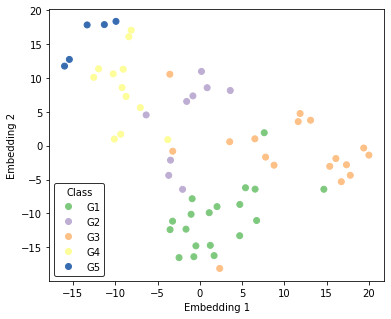

In [25]:
x = 0 # These are index values to the embedding
y = 1 # These are index values to the embedding
plt.figure(figsize=(6, 5))
plt.scatter(TCi2embedding[:, x], TCi2embedding[:, y], c=c, cmap=cmap)
plt.xlabel('Embedding {}'.format(x+1))
plt.ylabel('Embedding {}'.format(y+1))
# plt.title('Perp = 7')
plt.legend(handles,
           ["G1","G2","G3","G4","G5"],
           loc="lower left",
           edgecolor = "black",
           title='Class')
plt.show()
#mdlTCi2.kl_divergence_, mdlTCi2.n_iter_

## Careful use of *ilr* and ratios

Now we have a better idea of what's going on we can be more considerate of the CoDa method. For example, ratios should be treated separately from the closed data composition. Further, we can consider whether ratios are best calculated from the original data, or from the *clr*-transformed data

### Data shuffling

This first step creates a new dataframe ```df4``` that drops the ```Total``` and ```Eu/Eu*``` columns. The first is superfluous and the second has NaNs that cannot be resolved.

We then go on to check for NaNs in ratio columns as we can't simply impute new values here and then we fill NaNs in the remaining columns with zeros as these are going to be imputed using the multiplicative replacement technique (later).

The last part deals with units and then separates out the ratios as these need to be treated separately.

In [10]:
df4 = df_geochem.iloc[:,6:]
df4 = df4.drop(['Total','Eu/Eu*'],axis=1)
df4.columns

Index(['SiO2', 'TiO2', 'Al2O3', 'Fe2O3', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O',
       'P2O5', 'LOI', 'Ba', 'Pb', 'Rb', 'Sr', 'Nb', 'Th', 'U', 'Zr', 'La',
       'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu',
       'A/CNK', 'TZr', 'K/Rb', 'Rb/Sr'],
      dtype='object')

In [11]:
# This checks that the ratios are free of NaNs (answer should be false)
df4[['A/CNK','TZr','K/Rb','Rb/Sr']].isnull().values.any()

False

In [12]:
# Now fill NaNs with zeros
df4 = df4.fillna(0)

In [13]:
# Check where the ppm variables start
cols = list(df4.columns)
cols = cols[11:32]
# This loops through and creates a new col with ppm converted to %
for col in cols:
    col_pc = col + '_pc'
    df4[col_pc] = (df4[col]/10000) # 10000 is the factor required to make a %
# And this bit removes the old cols because they're redundant now
rm = df4.columns[11:32]
for i in rm:
    df4 = df4.drop(i, axis=1)

In [14]:
rm2 = df4.columns[11:15]
temp = df4.iloc[:,11:15]
for i in rm2:
    df4 = df4.drop(i, axis=1)
np4 = df4.to_numpy()

### CoDa transform

In here we impute values where zeros exist and check for closure.

Then we transform the compositional data (not including ratios) using the *ilr* tool. 

The *clr* tool is implemented to subsequently recalculate ratios in the second cell.

In [17]:
npm = skbc.multiplicative_replacement(np4)
npmc = skbc.closure(npm)
npi = skbc.ilr(npmc)
npc = skbc.clr(npmc)
df4i = pd.DataFrame(data=npi)
df4c = pd.DataFrame(data=npc)

In [32]:
df4c.columns = df4.columns
ACNK = df4c['Al2O3']/(df4c['Na2O']+df4c['K2O']+df4c['CaO'])
KRb = df4c['K2O']/df4c['Rb_pc']
RbSr = df4c['Rb_pc']/df4c['Sr_pc']
dftemp = pd.concat([ACNK,KRb,RbSr,temp['TZr']],axis=1)
dftemp.columns = ['A/CNK_clr','K/Rb_clr','Rb/Sr_clr','TZr']

### Calculate z-scores

Now we have calculated the *ilr*, we can start doing some analysis but itt is still important to calculate z-scores so we don't bias a particular variable if one is particularly large e.g. ```SiO2```

The last part is to concatenate the dataframes

In [33]:
# We have to create a list of strings for the column names here 
# Remember the ilr results in N-1 variables so they don't have proper names
a = range(0,(len(df4i.columns[0:31])))
col_n = list(map(str,a))
df4i.columns = col_n
cols = list(df4i.columns)
for col in cols:
    col_zscore = col + '_zscore'
    df4i[col_zscore] = (df4i[col] - df4i[col].mean())/df4i[col].std(ddof=0)

In [34]:
cols = list(temp.columns)
for col in temp:
    col_zscore = col + '_zscore'
    temp[col_zscore] = (temp[col] - temp[col].mean())/temp[col].std(ddof=0)

In [35]:
df4i = pd.concat([df4i,temp.iloc[:, 4:]], axis=1)
df4i.columns

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29', '30', '0_zscore', '1_zscore', '2_zscore',
       '3_zscore', '4_zscore', '5_zscore', '6_zscore', '7_zscore', '8_zscore',
       '9_zscore', '10_zscore', '11_zscore', '12_zscore', '13_zscore',
       '14_zscore', '15_zscore', '16_zscore', '17_zscore', '18_zscore',
       '19_zscore', '20_zscore', '21_zscore', '22_zscore', '23_zscore',
       '24_zscore', '25_zscore', '26_zscore', '27_zscore', '28_zscore',
       '29_zscore', '30_zscore', 'A/CNK_zscore', 'TZr_zscore', 'K/Rb_zscore',
       'Rb/Sr_zscore'],
      dtype='object')

#### Z-scores where ratios calculated with *clr*

In [36]:
cols = list(dftemp.columns)
for col in dftemp:
    col_zscore = col + '_zscore'
    dftemp[col_zscore] = (dftemp[col] - dftemp[col].mean())/dftemp[col].std(ddof=0)

In [37]:
df4ic = pd.concat([df4i,dftemp.iloc[:, 4:]], axis=1)
df4ic.columns

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29', '30', '0_zscore', '1_zscore', '2_zscore',
       '3_zscore', '4_zscore', '5_zscore', '6_zscore', '7_zscore', '8_zscore',
       '9_zscore', '10_zscore', '11_zscore', '12_zscore', '13_zscore',
       '14_zscore', '15_zscore', '16_zscore', '17_zscore', '18_zscore',
       '19_zscore', '20_zscore', '21_zscore', '22_zscore', '23_zscore',
       '24_zscore', '25_zscore', '26_zscore', '27_zscore', '28_zscore',
       '29_zscore', '30_zscore', 'A/CNK_zscore', 'TZr_zscore', 'K/Rb_zscore',
       'Rb/Sr_zscore', 'A/CNK_clr_zscore', 'K/Rb_clr_zscore',
       'Rb/Sr_clr_zscore', 'TZr_zscore'],
      dtype='object')

### Comparing original ratios and ratios calculated using *clr*-transformed data

So this is an incredibly useful test because I did the t-SNE before checking this and liked the *clr* ratios but as you can see this causes massive outliers in the data.

Based on this plot, original ratios appear better due to the generation of outliers

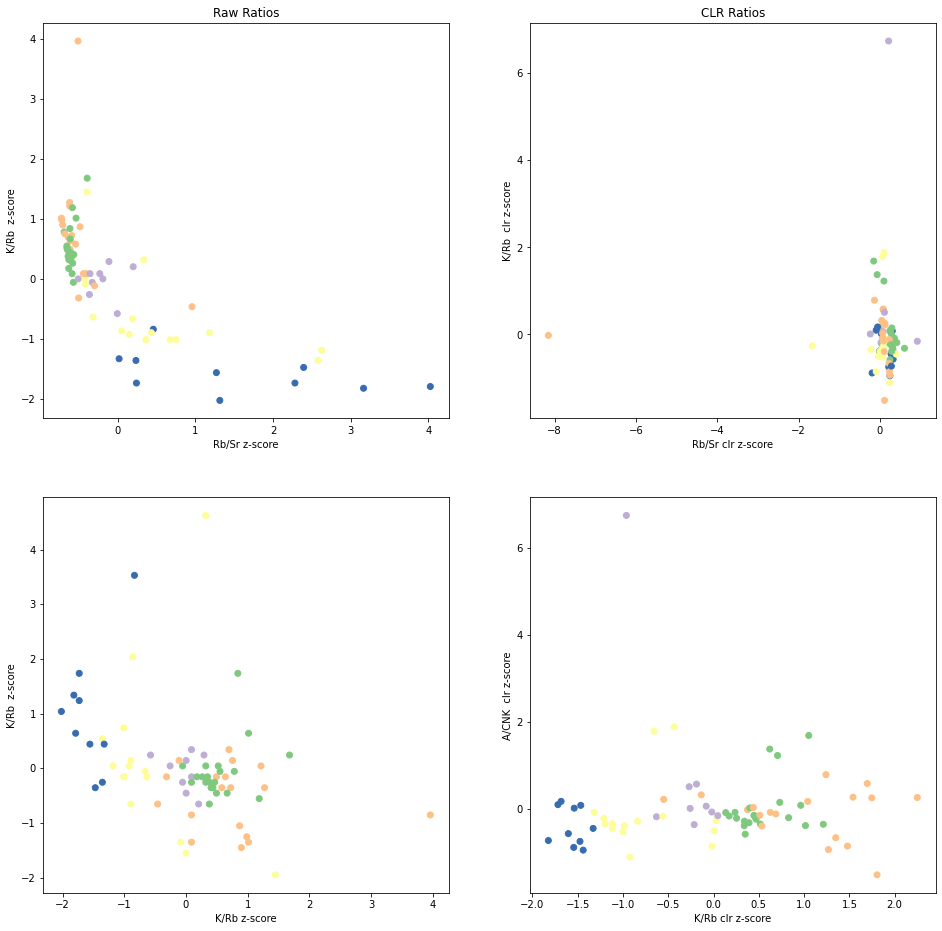

In [41]:
fig, [[ax1, ax2], [ax3, ax4]] = plt.subplots(2,2,figsize=(16, 16))
scatter1 = ax1.scatter(df4i['Rb/Sr_zscore'], 
                       df4i['K/Rb_zscore'], 
                       c = c2, 
                       cmap = cmap2)
scatter2 = ax2.scatter(df4ic['Rb/Sr_clr_zscore'], 
                       df4ic['A/CNK_clr_zscore'], 
                       c = c2, 
                       cmap = cmap2)
scatter3 = ax3.scatter(df4i['K/Rb_zscore'], 
                       df4i['A/CNK_zscore'], 
                       c = c2, 
                       cmap = cmap2)
scatter4 = ax4.scatter(df4ic['K/Rb_clr_zscore'], 
                       df4ic['A/CNK_clr_zscore'], 
                       c = c2, 
                       cmap = cmap2)
ax1.set_xlabel('Rb/Sr z-score')
ax1.set_ylabel('K/Rb  z-score')
ax2.set_xlabel('Rb/Sr clr z-score')
ax2.set_ylabel('K/Rb  clr z-score')
ax3.set_xlabel('K/Rb z-score')
ax3.set_ylabel('K/Rb  z-score')
ax4.set_xlabel('K/Rb clr z-score')
ax4.set_ylabel('A/CNK  clr z-score')
ax1.title.set_text('Raw Ratios')
ax2.title.set_text('CLR Ratios')

### t-SNE on the new *ilr* data

Here we compute some t-SNE models the first uses original ratios, the second uses ratios calculated from *clr* data

In [43]:
# Compute t-SNE embedding
from sklearn.manifold import TSNE
np.random.seed(250489) # to reproduce results
mdlTCi3 = TSNE(n_components=2, perplexity=9, n_iter=5000, learning_rate=30, early_exaggeration=8)
TCi3embedding = mdlTCi3.fit_transform(X=df4i.iloc[:, 31:])

In [44]:
# Compute t-SNE embedding
from sklearn.manifold import TSNE
np.random.seed(250489) # to reproduce results
mdlTCic4 = TSNE(n_components=2, perplexity=9, n_iter=5000, learning_rate=30, early_exaggeration=8)
TCic4embedding = mdlTCic4.fit_transform(X=df4ic.iloc[:, 31:])

#### New color ramp (you can ignore this)

The first cell just recalcs G1-5 with 73 samples, the second does for granite subtypes too (e.g. G1a, G3c)

In [40]:
dfa = df_geochem
# Create some new columns
dfa["Main Granite"] = ""
dfa["Subtype"] = ""
# Convert to string
dfa['Type'] = dfa['Type'].astype('str') 
dfa['Main Granite'] = dfa['Main Granite'].astype('str') 
dfa['Type']
# Split by each one
dfa[['Main Granite', 'Subtype']] = dfa['Type'].str.split(pat='a', expand=True) 
dfa[['Main Granite', 'Subtype']] = dfa['Main Granite'].str.split(pat='b', expand=True)
dfa[['Main Granite', 'Subtype']] = dfa['Main Granite'].str.split(pat='c', expand=True)
dfa[['Main Granite', 'Subtype']] = dfa['Main Granite'].str.split(pat='d', expand=True)
# Kill this column
del dfa['Subtype']
####
def f(df_col):
    if df_col == 'G1':
        val = 1
    elif df_col == 'G2':
        val = 2
    elif df_col == 'G3':
        val = 3
    elif df_col == 'G4':
        val = 4
    elif df_col == 'G5':
        val = 5
    else:
        val = NaN
    return val
dfa['G'] = dfa['Main Granite'].apply(f)
####
# Color categories
from palettable.colorbrewer.qualitative import Accent_5
c2 = dfa['G']
cmap2 = Accent_5.mpl_colormap
# G1 = Green
# G2 = Purple
# G3 = Orange
# G4 = Yellow
# G5 = Blue
#
# This line sets a scatter plot with the right handles and labels for calling later
ANK = dfa['Al2O3']/(dfa['Na2O']+dfa['K2O'])
scatter2 = plt.scatter(dfa['A/CNK'],ANK, c=c2, cmap=cmap2)
plt.close()
handles2, labels2 = scatter2.legend_elements()

In [55]:
dfa = df_geochem
# Create some new columns
dfa["Gn"] = ""
####
def f(df_col):
    if df_col == 'G1a':
        val = 1
    elif df_col == 'G1b':
        val = 2
    elif df_col == 'G1c':
        val = 3
    elif df_col == 'G2':
        val = 4
    elif df_col == 'G3a':
        val = 5
    elif df_col == 'G3b':
        val = 6
    elif df_col == 'G3c':
        val = 7
    elif df_col == 'G3d':
        val = 8
    elif df_col == 'G4a':
        val = 9
    elif df_col == 'G4b':
        val = 10
    elif df_col == 'G4c':
        val = 11
    elif df_col == 'G5a':
        val = 12
    elif df_col == 'G5b':
        val = 13
    else:
        val = NaN
    return val
dfa['Gn'] = dfa['Type'].apply(f)
####
# Color categories
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
# Channel:  RED    GREEN     BLUE  ALPHA

green = [49/256, 163/256, 94/256, 1.0]
purple =   [117/256,   107/256,   177/256, 1.0]
orange =   [253/256,   141/256,   60/256, 1.0]
yellow =   [255/256,   255/256,   178/256, 1.0]
blue =  [  0/256,  50/256, 100/256, 1.0]

newcmp = LinearSegmentedColormap.from_list("foo", [green, purple, orange, yellow, blue])
newlst = ListedColormap(newcmp(np.linspace(0, 1, 13)))

c3 = dfa['Gn']
cmap3 = newlst
# This line sets a scatter plot with the right handles and labels for calling later
ANK = dfa['Al2O3']/(dfa['Na2O']+dfa['K2O'])
scatter3 = plt.scatter(dfa['A/CNK'],ANK, c=c3, cmap=cmap3)
plt.close()
handles3, labels3 = scatter3.legend_elements()

#### And here we plot the *ilr* data with original ratios

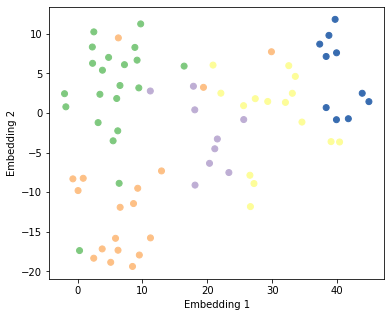

(0.2475372850894928, 2049)

In [45]:
x = 0 # These are index values to the embedding
y = 1 # These are index values to the embedding
plt.figure(figsize=(6, 5))
plt.scatter(TCi3embedding[:, x], TCi3embedding[:, y], c=c2, cmap=cmap2)
plt.xlabel('Embedding {}'.format(x+1))
plt.ylabel('Embedding {}'.format(y+1))
# plt.title('Perp = 7')
# plt.legend(handles,
#            ["G1","G2","G3","G4","G5"],
#            loc="lower right",
#            edgecolor = "black",
#            title='Class')
plt.show()
mdlTCi1.kl_divergence_, mdlTCi1.n_iter_

#### Dual plot comparing *ilr* and orig ratios with *ilr* and *clr* ratios

Dual plot herein, options to highlight subtypes

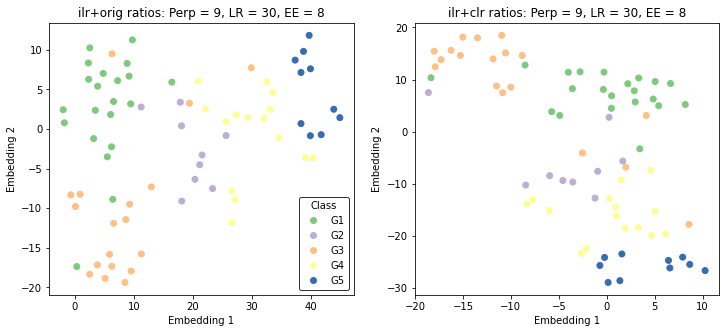

(0.29590997099876404, 0.293071448802948)

In [51]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12, 5))
scatter1 = ax1.scatter(TCi3embedding[:, 0], 
                       TCi3embedding[:, 1], 
                       c = c2, 
                       cmap = cmap2)
scatter2 = ax2.scatter(TCic4embedding[:, 0], 
                       TCic4embedding[:, 1],
                       c = c2,
                       cmap = cmap2,
#                        c = c3, 
#                        cmap = cmap3
                      )
ax1.set_xlabel('Embedding 1')
ax1.set_ylabel('Embedding 2')
ax2.set_xlabel('Embedding 1')
ax2.set_ylabel('Embedding 2')
ax1.title.set_text('ilr+orig ratios: Perp = {}, LR = {}, EE = {}'.format(mdlTCi3.perplexity,mdlTCi3.learning_rate,mdlTCi3.early_exaggeration))
ax2.title.set_text('ilr+clr ratios: Perp = {}, LR = {}, EE = {}'.format(mdlTCic4.perplexity,mdlTCic4.learning_rate,mdlTCic4.early_exaggeration))
legend1 = ax1.legend(handles,
                     ["G1","G2","G3","G4","G5"], 
                     loc='lower right',
                     edgecolor = "black",
                     title='Class')
# legend2 = ax2.legend(handles,
#                      ["G1a","G1b","G1c","G2","G3a","G3b","G3c","G3d","G4a","G4b","G4c","G5a","G5b"], 
#                      loc='lower left',
#                      edgecolor = "black",
#                      title='Class')
plt.show()
mdlTCi3.kl_divergence_,mdlTCic4.kl_divergence_

#### Comparing *ilr*+ratios with original t-SNE

This part compares the *ilr*-transformed t-SNE plot with the earlier preferred `mdlT3` data. It can be seen that the negatively correlated trend from the `mdlT3` data is removed when using *ilr* and the model space is used more effectively to separate out granite types. The KL divergence is not significantly different between the models. Remember, *ilr* data is difficult to interpret due to the N-1 elements but can still be further investigated by overlaying original geochemical data - this has not been done here but could be added.

G1 and G3 are clearly separable in the *ilr* t-SNE model and may highlight some possible misclassification. The position of G2 is not necessarily a genetic link. G4 appears less distinct but may contain subtypes (these may not map to the subtypes of Simons et al. 2016). G5 is distinct but again may have subtypes. A comparison back to the orignally samples rocks may be advantageous in understanding these possible misclassifications and potential subtypes.

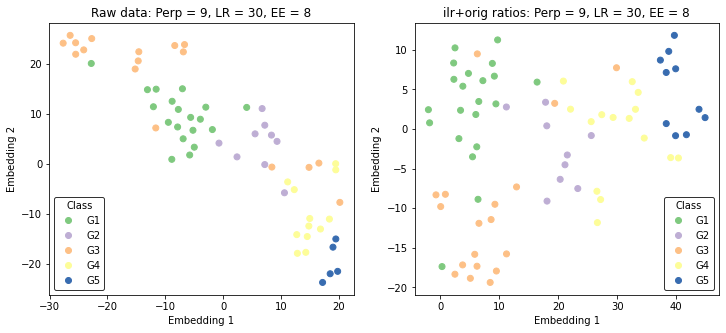

(0.29590997099876404, 0.293071448802948)

In [52]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12, 5))
scatter1 = ax1.scatter(T3embedding[:, 0], 
                       T3embedding[:, 1], 
                       c = c, 
                       cmap = cmap)
scatter2 = ax2.scatter(TCi3embedding[:, 0], 
                       TCi3embedding[:, 1],
                       c = c2,
                       cmap = cmap2,
#                        c = c3, 
#                        cmap = cmap3
                      )
ax1.set_xlabel('Embedding 1')
ax1.set_ylabel('Embedding 2')
ax2.set_xlabel('Embedding 1')
ax2.set_ylabel('Embedding 2')
ax1.title.set_text('Raw data: Perp = {}, LR = {}, EE = {}'.format(mdlTCi3.perplexity,mdlTCi3.learning_rate,mdlTCi3.early_exaggeration))
ax2.title.set_text('ilr+orig ratios: Perp = {}, LR = {}, EE = {}'.format(mdlTCic4.perplexity,mdlTCic4.learning_rate,mdlTCic4.early_exaggeration))
legend1 = ax1.legend(handles,
                     ["G1","G2","G3","G4","G5"], 
                     loc='lower left',
                     edgecolor = "black",
                     title='Class')
legend2 = ax2.legend(handles,
                     ["G1","G2","G3","G4","G5"], 
                     loc='lower right',
                     edgecolor = "black",
                     title='Class')
plt.show()
mdlTCi3.kl_divergence_,mdlTCic4.kl_divergence_

## Let's try some UMAP

# MISC: useful plotting examples 

Here's an example of fixing the color mapping to legend from SWUNG

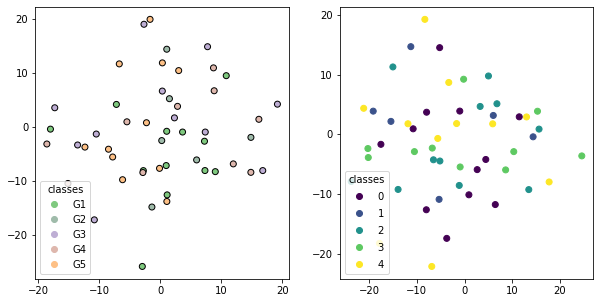

In [169]:
from palettable.colorbrewer.qualitative import Accent_3
import matplotlib.pyplot as plt
import numpy as np
n = 50
colDict = {"A": Accent_3.hex_colors[0],
           "B": Accent_3.hex_colors[1],
           "C": Accent_3.hex_colors[2]}
c = np.random.randint(5, size=n)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
scatter1 = ax1.scatter(np.random.randn(n) * 10, np.random.randn(n) * 10, c=c, cmap=Accent_3.mpl_colormap, edgecolor='black')
scatter2 = ax2.scatter(np.random.randn(n) * 10, np.random.randn(n) * 10, c=c)
handles, labels = scatter1.legend_elements()
legend1 = ax1.legend(handles,["G1","G2","G3","G4","G5"], loc='lower left', title='classes')
legend2 = ax2.legend(*scatter2.legend_elements(), loc='lower left', title='classes')

# Playground

Here you can test data/code before inputting into the main workflow

In [18]:
plot_list

Index(['SiO2_zscore', 'TiO2_zscore', 'Al2O3_zscore', 'Fe2O3_zscore',
       'MnO_zscore', 'MgO_zscore', 'CaO_zscore', 'Na2O_zscore', 'K2O_zscore',
       'P2O5_zscore', 'Ba_zscore', 'Pb_zscore', 'Rb_zscore', 'Sr_zscore',
       'Nb_zscore', 'Th_zscore', 'U_zscore', 'Zr_zscore', 'La_zscore',
       'Ce_zscore', 'Pr_zscore', 'Nd_zscore', 'Sm_zscore', 'Eu_zscore',
       'Gd_zscore', 'Dy_zscore', 'Ho_zscore', 'Er_zscore', 'Tm_zscore',
       'Yb_zscore', 'Lu_zscore', 'A/CNK_zscore', 'TZr_zscore', 'Eu/Eu*_zscore',
       'K/Rb_zscore', 'Rb/Sr_zscore'],
      dtype='object')

In [120]:
df4c['Rb_pc'].values[11] / df4c['Sr_pc'].values[11]

-531.5464448945986

In [109]:
df4.columns

Index(['SiO2', 'TiO2', 'Al2O3', 'Fe2O3', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O',
       'P2O5', 'LOI', 'Ba_pc', 'Pb_pc', 'Rb_pc', 'Sr_pc', 'Nb_pc', 'Th_pc',
       'U_pc', 'Zr_pc', 'La_pc', 'Ce_pc', 'Pr_pc', 'Nd_pc', 'Sm_pc', 'Eu_pc',
       'Gd_pc', 'Dy_pc', 'Ho_pc', 'Er_pc', 'Tm_pc', 'Yb_pc', 'Lu_pc'],
      dtype='object')

In [18]:
Check out anhydrous vs hydrous

SyntaxError: invalid syntax (<ipython-input-18-45d00da062a1>, line 1)

In [22]:
df4i.head()

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
0,3.674087,-0.863583,0.851197,4.456104,1.107378,0.801493,-0.530403,-1.178029,1.759443,0.277675,...,3.151079,4.565682,6.626628,4.392808,4.588904,6.111472,4.987300,6.762807,4.770967,6.436226
1,3.667630,-0.850363,0.824143,4.254593,1.077877,0.774025,-0.460554,-1.071909,1.854011,0.076695,...,3.161839,4.622474,6.762067,4.484910,4.731389,6.289084,5.147158,6.906676,4.925775,6.628366
2,3.755111,-0.876528,0.872756,4.409719,1.098487,0.752158,-0.567375,-1.095765,1.824290,0.151577,...,3.234723,4.686671,6.851086,4.530205,4.749541,6.313963,5.154913,6.907997,4.901712,6.636195
3,4.599419,-1.334122,1.019787,4.294887,2.320682,0.838294,-1.323697,-1.450648,1.118997,-0.178392,...,4.115726,5.360343,8.596574,5.003569,4.791321,6.257002,4.978572,6.550701,4.370261,6.082187
4,4.670747,-1.358339,0.972450,4.018505,2.770238,0.775091,-1.384067,-1.479374,1.099650,-0.006296,...,4.113010,5.350968,8.587582,4.994930,4.794621,6.248560,4.970427,6.542833,4.346117,6.075352
